# Packages

In [46]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle
import wandb

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
import functions_enc as f
import function_depot as fd

# Functions

## Heatmaps

In [47]:
def create_conditional_encoder_heatmaps(
    folder_path,
    super_test=False,
    test_only=True,
    train_only=False,
    bins=[0.1, 0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
):
    """
    Generate heatmaps of conditional encoder performance across bin sizes and thresholds.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing conditional encoder output .parquet files
    super_test : bool, default=False
        If True, appends '_super_test' to folder path
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    train_only : bool, default=False
        If True, only use spectra where train==1 (training set)
    bins : list, default=[0.1, 0.5, 1, 10, 100, 500]
        List of bin sizes to include in heatmap
    thresholds : list, default=[0.01, 0.05, 0.1, 0.5, 10, 100]
        List of threshold values to include in heatmap
    vmin : float, default=1.0
        Minimum value for heatmap color scale
    vmax : float, default=100.0
        Maximum value for heatmap color scale
    figsize : tuple, default=(12, 8)
        Figure size for heatmaps
    save_plots : bool, default=False
        Whether to save the plots to disk
    save_path : str, optional
        Path where to save the plots (required if save_plots=True)
    
    Returns:
    --------
    None
        Displays heatmaps only
    """
    import os
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Validate that both test_only and train_only are not True
    if test_only and train_only:
        raise ValueError("Cannot set both test_only=True and train_only=True. Please choose one or set both to False.")
    
    # Select folder based on super_test flag
    if super_test:
        if folder_path.endswith('/'):
            active_folder = folder_path[:-1] + '_super_test'
        else:
            active_folder = folder_path + '_super_test'
    else:
        active_folder = folder_path
    
    # Get all .parquet files in the folder
    parquet_files = [f for f in os.listdir(active_folder) if f.endswith('.parquet')]
    dataset_names = [f.replace('.parquet', '') for f in parquet_files]
    
    # Function to parse dataset names (defined early for filtering)
    def parse_dataset_name(dataset_name):
        """Extract bin size and threshold from dataset name"""
        # Remove 'super_test_' prefix if present
        if dataset_name.startswith('super_test_'):
            dataset_name = dataset_name.replace('super_test_', '', 1)
        
        # Remove 'cond_enc_' prefix
        name_part = dataset_name.replace('cond_enc_', '')
        
        # Handle thresh_zero case (no threshold)
        if 'thresh_zero' in name_part:
            # Extract bin size
            bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
            bin_size = float(bin_part.replace('_', '.'))
            threshold = 0.0
        else:
            # Extract bin size and threshold
            parts = name_part.split('_thresh')
            bin_part = parts[0].replace('bin', '')
            bin_size = float(bin_part.replace('_', '.'))
            
            thresh_part = parts[1].split('_df_spectra')[0]
            threshold = float(thresh_part.replace('_', '.'))
        
        return bin_size, threshold
    
    # Filter to only process files matching specified bins and thresholds
    filtered_dataset_names = []
    for dataset_name in dataset_names:
        try:
            bin_size, threshold = parse_dataset_name(dataset_name)
            # Only include if both bin and threshold are in specified lists
            if bin_size in bins and threshold in thresholds:
                filtered_dataset_names.append(dataset_name)
        except Exception:
            # Skip files that don't match expected naming pattern
            continue
    
    print(f"Found {len(dataset_names)} total files, processing {len(filtered_dataset_names)} matching specified bins/thresholds")
    
    # Initialize storage for results (percent error only)
    results_percent_error = []
    
    # Process ONLY filtered datasets
    for dataset_name in sorted(filtered_dataset_names):
        try:
            # Load the dataset
            file_path = os.path.join(active_folder, f"{dataset_name}.parquet")
            df = pd.read_parquet(file_path)
            
            # Filter for test set only if requested
            if test_only:
                if 'train' in df.columns:
                    df = df[df['train'] == 0]
                else:
                    print(f"Warning: 'train' column not found in {dataset_name}, using all data")
            
            # Filter for training set only if requested
            if train_only:
                if 'train' in df.columns:
                    df = df[df['train'] == 1]
                else:
                    print(f"Warning: 'train' column not found in {dataset_name}, using all data")
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
            y_true_response = df['Response']  # True toxicity values
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:  # Skip if too few samples
                continue
            
            # Calculate absolute percent error on original scale (Response)
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate median and mean absolute percent error
            median_percent_error = np.median(individual_errors)
            mean_percent_error = np.mean(individual_errors)
            
            # Store results
            results_percent_error.append({
                'Dataset': dataset_name,
                'Median_Percent_Error': median_percent_error,
                'Mean_Percent_Error': mean_percent_error,
                'Samples': len(y_pred_response_clean)
            })
            
        except Exception as e:
            continue
    
    # Convert results to DataFrame
    df_results = pd.DataFrame(results_percent_error)
    
    # Add bin_size and threshold columns (using parse_dataset_name already defined above)
    bin_sizes = []
    thresholds_list = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds_list.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds_list
    
    # Remove duplicates
    df_results = df_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
    
    # Create pivot tables
    median_percent_error_pivot = df_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
    mean_percent_error_pivot = df_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')
    
    # Reindex pivot tables with specified bins and thresholds
    median_percent_error_pivot = median_percent_error_pivot.reindex(columns=thresholds, index=bins)
    mean_percent_error_pivot = mean_percent_error_pivot.reindex(columns=thresholds, index=bins)
    
    # Function to create heatmaps
    def create_heatmap(pivot_data, metric_name, cmap='RdYlBu_r'):
        """Create a detailed heatmap for a single metric"""
        plt.figure(figsize=figsize)
        
        # Create heatmap with larger annotation font size
        sns.heatmap(
            pivot_data, 
            annot=True, 
            fmt='.1f', 
            cmap=cmap,
            square=False,
            linewidths=0.5,
            vmin=vmin,
            vmax=vmax,
            cbar_kws={'label': f'{metric_name}', 'shrink': 0.8},
            annot_kws={"size": 18}  # <-- Increase number font size here
        )
        
        # Build title with test_only/train_only indicator
        test_type = "Super Test" if super_test else "Validation"
        if test_only:
            data_type = " (Test Set Only)"
        elif train_only:
            data_type = " (Training Set Only)"
        else:
            data_type = ""
        plt.title(f'Conditional Encoder ({test_type}): {metric_name} by Bin Size and Threshold{data_type}', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Threshold Value', fontsize=14)
        plt.ylabel('Bin Size', fontsize=14)
        plt.gca().invert_yaxis()
        
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        
        # Add text annotation for best performance
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
        
        plt.tight_layout()
        
        # Save plot if requested
        if save_plots:
            if save_path is None:
                raise ValueError("save_path must be provided when save_plots=True")
            test_suffix = "_SuperTest" if super_test else "_Val"
            if test_only:
                data_suffix = "_TestOnly"
            elif train_only:
                data_suffix = "_TrainOnly"
            else:
                data_suffix = ""
            filename = f"CondEnc_{metric_name}_by_Bin_Size_and_Threshold{test_suffix}{data_suffix}.png"
            plt.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')
        
        plt.show()
    
    # Create heatmaps
    create_heatmap(median_percent_error_pivot, 'Median_Absolute_Percent_Error')
    create_heatmap(mean_percent_error_pivot, 'Mean_Absolute_Percent_Error')


In [48]:
def create_conditional_encoder_heatmaps_flexible(
    folder_path,
    file_prefix='cond_enc',
    pred_col=None,  # optional: explicit prediction column
    super_test=False,
    test_only=True,
    bins=[0.1, 0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
):
    """
    Generate heatmaps of model performance across bin sizes and thresholds.
    Works with different file naming conventions by specifying the prefix.
    """
    import os
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Select folder based on super_test flag
    if super_test:
        if folder_path.endswith('/'):
            active_folder = folder_path[:-1] + '_super_test'
        else:
            active_folder = folder_path + '_super_test'
    else:
        active_folder = folder_path

    parquet_files = [f for f in os.listdir(active_folder) if f.endswith('.parquet')]
    dataset_names = [f.replace('.parquet', '') for f in parquet_files]

    print(f"Found {len(dataset_names)} total files in {active_folder}")

    def parse_dataset_name(dataset_name, prefix):
        """Extract bin size and threshold from dataset name"""
        if dataset_name.startswith('super_test_'):
            dataset_name = dataset_name.replace('super_test_', '', 1)

        # robust prefix handling (with/without trailing underscore)
        clean_prefix = prefix.rstrip('_')
        if not dataset_name.startswith(f"{clean_prefix}_"):
            raise ValueError(f"Dataset '{dataset_name}' does not match prefix '{clean_prefix}'")

        name_part = dataset_name[len(clean_prefix) + 1:]

        if 'thresh_zero' in name_part:
            bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
            bin_size = float(bin_part.replace('_', '.'))
            threshold = 0.0
        else:
            parts = name_part.split('_thresh')
            bin_part = parts[0].replace('bin', '')
            bin_size = float(bin_part.replace('_', '.'))

            thresh_part = parts[1].split('_df_spectra')[0]
            threshold = float(thresh_part.replace('_', '.'))

        return bin_size, threshold

    filtered_dataset_names = []
    for dataset_name in dataset_names:
        try:
            bin_size, threshold = parse_dataset_name(dataset_name, file_prefix)
            if bin_size in bins and threshold in thresholds:
                filtered_dataset_names.append(dataset_name)
        except Exception:
            continue

    print(f"Processing {len(filtered_dataset_names)} files matching specified bins/thresholds with prefix '{file_prefix}'")

    results_percent_error = []

    for dataset_name in sorted(filtered_dataset_names):
        try:
            file_path = os.path.join(active_folder, f"{dataset_name}.parquet")
            df = pd.read_parquet(file_path)

            if test_only:
                if 'train' in df.columns:
                    df = df[df['train'] == 0]
                else:
                    print(f"Warning: 'train' column not found in {dataset_name}, using all data")

            # auto-detect prediction column if not provided
            pred_col_local = pred_col
            if pred_col_local is None:
                for c in ("cond_tox_pred", "rf_tox_pred"):
                    if c in df.columns:
                        pred_col_local = c
                        break
            if pred_col_local is None:
                raise KeyError("No prediction column found. Expected one of: cond_tox_pred, rf_tox_pred")

            y_pred_log = df[pred_col_local]
            y_true_response = df['Response']

            y_pred_response = np.exp(y_pred_log)

            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]

            if len(y_pred_response_clean) < 10:
                continue

            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            median_percent_error = np.median(individual_errors)
            mean_percent_error = np.mean(individual_errors)

            results_percent_error.append({
                'Dataset': dataset_name,
                'Median_Percent_Error': median_percent_error,
                'Mean_Percent_Error': mean_percent_error,
                'Samples': len(y_pred_response_clean)
            })

        except Exception as e:
            print(f"Error processing {dataset_name}: {str(e)}")
            continue

    df_results = pd.DataFrame(results_percent_error)

    if len(df_results) == 0:
        print(f"ERROR: No valid data found. Check prefix '{file_prefix}', prediction column, and required fields.")
        return

    bin_sizes = []
    thresholds_list = []
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name, file_prefix)
        bin_sizes.append(bin_size)
        thresholds_list.append(threshold)

    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds_list
    df_results = df_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

    median_percent_error_pivot = df_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
    mean_percent_error_pivot = df_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')

    median_percent_error_pivot = median_percent_error_pivot.reindex(columns=thresholds, index=bins)
    mean_percent_error_pivot = mean_percent_error_pivot.reindex(columns=thresholds, index=bins)

    def create_heatmap(pivot_data, metric_name, cmap='RdYlBu_r'):
        plt.figure(figsize=figsize)
        sns.heatmap(
            pivot_data,
            annot=True,
            fmt='.1f',
            cmap=cmap,
            square=False,
            linewidths=0.5,
            vmin=vmin,
            vmax=vmax,
            cbar_kws={'label': f'{metric_name}', 'shrink': 0.8},
            annot_kws={"size": 18}  # <-- Increase number font size here
        )

        test_type = "Super Test" if super_test else "Validation"
        data_type = " (Test Set Only)" if test_only else ""
        model_type = file_prefix.replace('_', ' ').title()
        plt.title(f'{model_type} ({test_type}): {metric_name} by Bin Size and Threshold{data_type}', fontsize=16, fontweight='bold')
        plt.xlabel('Threshold Value', fontsize=14)
        plt.ylabel('Bin Size', fontsize=14)
        plt.gca().invert_yaxis()
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)

        best_val = pivot_data.min().min()
        plt.text(
            0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%',
            transform=plt.gca().transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top'
        )

        plt.tight_layout()

        if save_plots:
            if save_path is None:
                raise ValueError("save_path must be provided when save_plots=True")
            test_suffix = "_SuperTest" if super_test else "_Val"
            test_only_suffix = "_TestOnly" if test_only else ""
            filename = f"{file_prefix}_{metric_name}_by_Bin_Size_and_Threshold{test_suffix}{test_only_suffix}.png"
            plt.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')

        plt.show()

    create_heatmap(median_percent_error_pivot, 'Median_Absolute_Percent_Error')
    create_heatmap(mean_percent_error_pivot, 'Mean_Absolute_Percent_Error')


## Confusion Matrix

In [49]:
def create_toxicity_confusion_matrix(
    file_path=None,
    folder_path=None,
    file_name=None,
    super_test=False,
    test_only=False,
    figsize=(10, 8),
    save_plot=False,
    save_path=None
):
    """
    Create a percentage-based confusion matrix for toxicity classification.
    Each row shows how the actual label was distributed across predictions.
    
    Parameters:
    -----------
    file_path : str, optional
        Full path to a specific parquet file to analyze
    folder_path : str, optional
        Path to folder containing validation outputs (used if file_path not provided)
    file_name : str, optional
        Name of specific file to load from folder_path (e.g., 'cond_enc_bin1_thresh0_05_df_spectra.parquet')
    super_test : bool, default=False
        If True, appends '_super_test' to folder path and prepends 'super_test_' to filename
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    figsize : tuple, default=(10, 8)
        Figure size for the confusion matrix
    save_plot : bool, default=False
        Whether to save the plot to disk
    save_path : str, optional
        Path where to save the plot (required if save_plot=True)
    
    Returns:
    --------
    tuple
        (confusion_matrix_percentage, dataframe)
    """
    from sklearn.metrics import confusion_matrix
    
    # Determine which file to load
    if file_path is None:
        if folder_path is None:
            raise ValueError("Either file_path or folder_path must be provided")
        if file_name is None:
            raise ValueError("file_name must be provided when using folder_path")
        
        # Modify folder and filename for super_test
        if super_test:
            if folder_path.endswith('/'):
                active_folder = folder_path[:-1] + '_super_test'
            else:
                active_folder = folder_path + '_super_test'
            
            # Prepend 'super_test_' to filename if not already present
            if not file_name.startswith('super_test_'):
                active_file_name = 'super_test_' + file_name
            else:
                active_file_name = file_name
        else:
            active_folder = folder_path
            active_file_name = file_name
        
        file_path = os.path.join(active_folder, active_file_name)
    
    # Load the data
    print(f"Loading: {file_path}")
    df = pd.read_parquet(file_path)
    
    # Filter for test set only if requested
    if test_only:
        if 'train' in df.columns:
            original_count = len(df)
            df = df[df['train'] == 0].copy()
            filtered_count = len(df)
            print(f"Filtered to test set only: {filtered_count} samples")
        else:
            print(f"Warning: 'train' column not found, using all data")
    
    # Get predicted toxicity from cond_tox_pred (log scale) and convert to Response scale
    y_pred_log = df['cond_tox_pred']
    y_pred_response = np.exp(y_pred_log)
    
    # Get true toxicity
    y_true_response = df['Response']
    
    # Remove any NaN values
    valid_mask = ~(y_pred_response.isna() | y_true_response.isna())
    y_pred_response_clean = y_pred_response[valid_mask]
    y_true_response_clean = y_true_response[valid_mask]
    
    # Assign toxicity levels using fd.assign_tox_level
    y_pred_classes = y_pred_response_clean.apply(fd.assign_tox_level)
    y_true_classes = y_true_response_clean.apply(fd.assign_tox_level)
    
    # Convert tox_level_X strings to integer classes (0-4)
    y_pred_classes_int = y_pred_classes.str.replace('tox_level_', '').astype(int)
    y_true_classes_int = y_true_classes.str.replace('tox_level_', '').astype(int)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true_classes_int, y_pred_classes_int, labels=[0, 1, 2, 3, 4])
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Define class labels
    class_labels = ['Tox Level 0', 'Tox Level 1', 'Tox Level 2', 'Tox Level 3', 'Tox Level 4']
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt='.1f', 
                cmap='Blues',
                xticklabels=class_labels, 
                yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'},
                square=True)
    
    # Build title with test_only indicator
    test_type = "Super Test" if super_test else "Validation"
    data_type = " (Test Only)" if test_only else ""
    dataset_name = os.path.basename(file_path).replace('.parquet', '')
    
    plt.title(f'Confusion Matrix - {test_type} Percentages{data_type}\n{dataset_name}', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    # Save plot if requested
    if save_plot:
        if save_path is None:
            raise ValueError("save_path must be provided when save_plot=True")
        test_suffix = "_SuperTest" if super_test else "_Val"
        test_only_suffix = "_TestOnly" if test_only else ""
        save_filename = f"ConfusionMatrix_Percent_{dataset_name}{test_suffix}{test_only_suffix}.png"
        full_save_path = os.path.join(save_path, save_filename)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to: {full_save_path}")
    
    plt.show()
    
    return cm_percent, df

In [50]:
def create_toxicity_confusion_matrix_flexible(
    file_path=None,
    folder_path=None,
    file_name=None,
    pred_col=None,  # optional: explicit prediction column
    super_test=False,
    test_only=False,
    figsize=(10, 8),
    save_plot=False,
    save_path=None
):
    """
    Create a percentage-based confusion matrix for toxicity classification.
    Each row shows how the actual label was distributed across predictions.
    Flexible version that accepts a custom prediction column.
    
    Parameters:
    -----------
    file_path : str, optional
        Full path to a specific parquet file to analyze
    folder_path : str, optional
        Path to folder containing validation outputs (used if file_path not provided)
    file_name : str, optional
        Name of specific file to load from folder_path (e.g., 'cond_enc_bin1_thresh0_05_df_spectra.parquet')
    pred_col : str, optional
        Name of the prediction column to use. If None, auto-detects from ['cond_tox_pred', 'rf_tox_pred', 'rf_direct_tox_pre']
    super_test : bool, default=False
        If True, appends '_super_test' to folder path 
        and prepends 'super_test_' to filename
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    figsize : tuple, default=(10, 8)
        Figure size for the confusion matrix
    save_plot : bool, default=False
        Whether to save the plot to disk
    save_path : str, optional
        Path where to save the plot (required if save_plot=True)
    
    Returns:
    --------
    tuple
        (confusion_matrix_percentage, dataframe)
    """
    from sklearn.metrics import confusion_matrix
    
    # Determine which file to load
    if file_path is None:
        if folder_path is None:
            raise ValueError("Either file_path or folder_path must be provided")
        if file_name is None:
            raise ValueError("file_name must be provided when using folder_path")
        
        # Modify folder and filename for super_test
        if super_test:
            if folder_path.endswith('/'):
                active_folder = folder_path[:-1] + '_super_test'
            else:
                active_folder = folder_path + '_super_test'
            
            # Prepend 'super_test_' to filename if not already present
            if not file_name.startswith('super_test_'):
                active_file_name = 'super_test_' + file_name
            else:
                active_file_name = file_name
        else:
            active_folder = folder_path
            active_file_name = file_name
        
        file_path = os.path.join(active_folder, active_file_name)
    
    # Load the data
    print(f"Loading: {file_path}")
    df = pd.read_parquet(file_path)
    
    # Filter for test set only if requested
    if test_only:
        if 'train' in df.columns:
            original_count = len(df)
            df = df[df['train'] == 0].copy()
            filtered_count = len(df)
            print(f"Filtered to test set only: {filtered_count} samples")
        else:
            print(f"Warning: 'train' column not found, using all data")
    
    # Auto-detect prediction column if not provided
    pred_col_local = pred_col
    if pred_col_local is None:
        for c in ['cond_tox_pred', 'rf_tox_pred', 'rf_direct_tox_pre']:
            if c in df.columns:
                pred_col_local = c
                print(f"Auto-detected prediction column: {pred_col_local}")
                break
    if pred_col_local is None:
        raise KeyError("No prediction column found. Expected one of: cond_tox_pred, rf_tox_pred, rf_direct_tox_pre")
    
    # Get predicted toxicity from prediction column (log scale) and convert to Response scale
    y_pred_log = df[pred_col_local]
    y_pred_response = np.exp(y_pred_log)
    
    # Get true toxicity
    y_true_response = df['Response']
    
    # Remove any NaN values
    valid_mask = ~(y_pred_response.isna() | y_true_response.isna())
    y_pred_response_clean = y_pred_response[valid_mask]
    y_true_response_clean = y_true_response[valid_mask]
    
    # Assign toxicity levels using fd.assign_tox_level
    y_pred_classes = y_pred_response_clean.apply(fd.assign_tox_level)
    y_true_classes = y_true_response_clean.apply(fd.assign_tox_level)
    
    # Convert tox_level_X strings to integer classes (0-4)
    y_pred_classes_int = y_pred_classes.str.replace('tox_level_', '').astype(int)
    y_true_classes_int = y_true_classes.str.replace('tox_level_', '').astype(int)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true_classes_int, y_pred_classes_int, labels=[0, 1, 2, 3, 4])
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Define class labels
    class_labels = ['Tox Level 0', 'Tox Level 1', 'Tox Level 2', 'Tox Level 3', 'Tox Level 4']
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt='.1f', 
                cmap='Blues',
                xticklabels=class_labels, 
                yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'},
                square=True)
    
    # Build title with test_only indicator
    test_type = "Super Test" if super_test else "Validation"
    data_type = " (Test Only)" if test_only else ""
    dataset_name = os.path.basename(file_path).replace('.parquet', '')
    
    plt.title(f'Confusion Matrix - {test_type} Percentages{data_type}\n{dataset_name}', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    # Save plot if requested
    if save_plot:
        if save_path is None:
            raise ValueError("save_path must be provided when save_plot=True")
        test_suffix = "_SuperTest" if super_test else "_Val"
        test_only_suffix = "_TestOnly" if test_only else ""
        save_filename = f"ConfusionMatrix_Percent_{dataset_name}{test_suffix}{test_only_suffix}.png"
        full_save_path = os.path.join(save_path, save_filename)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to: {full_save_path}")
    
    plt.show()
    
    return cm_percent, df

### The First Versions Without the Easy Super test capatability

In [51]:
# Conf matrix
def create_toxicity_confusion_matrix_og(
    file_path=None,
    folder_path=None,
    file_name=None,
    folder_path_super_test=None,
    super_test=False,
    test_only=False,
    figsize=(10, 8),
    save_plot=False,
    save_path=None
):
    """
    Create a percentage-based confusion matrix for toxicity classification.
    Each row shows how the actual label was distributed across predictions.
    
    Parameters:
    -----------
    file_path : str, optional
        Full path to a specific parquet file to analyze
    folder_path : str, optional
        Path to folder containing validation outputs (used if file_path not provided)
    file_name : str, optional
        Name of specific file to load from folder_path (e.g., 'cond_enc_bin1_thresh0_05_df_spectra.parquet')
    folder_path_super_test : str, optional
        Path to folder containing super test outputs
    super_test : bool, default=False
        If True, use folder_path_super_test; if False, use folder_path
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    figsize : tuple, default=(10, 8)
        Figure size for the confusion matrix
    save_plot : bool, default=False
        Whether to save the plot to disk
    save_path : str, optional
        Path where to save the plot (required if save_plot=True)
    
    Returns:
    --------
    tuple
        (confusion_matrix_percentage, dataframe)
    """
    from sklearn.metrics import confusion_matrix
    
    # Determine which file to load
    if file_path is None:
        # Select folder based on super_test flag
        if super_test:
            if folder_path_super_test is None:
                raise ValueError("folder_path_super_test must be provided when super_test=True")
            active_folder = folder_path_super_test
        else:
            if folder_path is None:
                raise ValueError("Either file_path or folder_path must be provided")
            active_folder = folder_path
        
        if file_name is None:
            raise ValueError("file_name must be provided when using folder_path")
        
        file_path = os.path.join(active_folder, file_name)
    
    # Load the data
    print(f"Loading: {file_path}")
    df = pd.read_parquet(file_path)
    
    # Filter for test set only if requested
    if test_only:
        if 'train' in df.columns:
            original_count = len(df)
            df = df[df['train'] == 0].copy()
            filtered_count = len(df)
            print(f"Filtered to test set only: {filtered_count} samples")
        else:
            print(f"Warning: 'train' column not found, using all data")
    
    # Get predicted toxicity from cond_tox_pred (log scale) and convert to Response scale
    y_pred_log = df['cond_tox_pred']
    y_pred_response = np.exp(y_pred_log)
    
    # Get true toxicity
    y_true_response = df['Response']
    
    # Remove any NaN values
    valid_mask = ~(y_pred_response.isna() | y_true_response.isna())
    y_pred_response_clean = y_pred_response[valid_mask]
    y_true_response_clean = y_true_response[valid_mask]
    
    # Assign toxicity levels using fd.assign_tox_level
    y_pred_classes = y_pred_response_clean.apply(fd.assign_tox_level)
    y_true_classes = y_true_response_clean.apply(fd.assign_tox_level)
    
    # Convert tox_level_X strings to integer classes (0-4)
    y_pred_classes_int = y_pred_classes.str.replace('tox_level_', '').astype(int)
    y_true_classes_int = y_true_classes.str.replace('tox_level_', '').astype(int)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true_classes_int, y_pred_classes_int, labels=[0, 1, 2, 3, 4])
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Define class labels
    class_labels = ['Tox Level 0', 'Tox Level 1', 'Tox Level 2', 'Tox Level 3', 'Tox Level 4']
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt='.1f', 
                cmap='Blues',
                xticklabels=class_labels, 
                yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'},
                square=True)
    
    # Build title with test_only indicator
    test_type = "Super Test" if super_test else "Validation"
    data_type = " (Test Only)" if test_only else ""
    dataset_name = os.path.basename(file_path).replace('.parquet', '')
    
    plt.title(f'Confusion Matrix - {test_type} Percentages{data_type}\n{dataset_name}', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    # Save plot if requested
    if save_plot:
        if save_path is None:
            raise ValueError("save_path must be provided when save_plot=True")
        test_suffix = "_SuperTest" if super_test else "_Val"
        test_only_suffix = "_TestOnly" if test_only else ""
        save_filename = f"ConfusionMatrix_Percent_{dataset_name}{test_suffix}{test_only_suffix}.png"
        full_save_path = os.path.join(save_path, save_filename)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to: {full_save_path}")
    
    plt.show()
    
    return cm_percent, df

In [52]:
# Violin plot
def create_toxicity_violin_plot_og(
    file_path=None,
    folder_path=None,
    file_name=None,
    folder_path_super_test=None,
    super_test=False,
    test_only=False,
    figsize=(12, 8),
    save_plot=False,
    save_path=None
):
    """
    Create a violin plot showing the distribution of Response (LD50) values for each toxicity level.
    
    Parameters:
    -----------
    file_path : str, optional
        Full path to a specific parquet file to analyze
    folder_path : str, optional
        Path to folder containing validation outputs (used if file_path not provided)
    file_name : str, optional
        Name of specific file to load from folder_path (e.g., 'cond_enc_bin1_thresh0_05_df_spectra.parquet')
    folder_path_super_test : str, optional
        Path to folder containing super test outputs
    super_test : bool, default=False
        If True, use folder_path_super_test; if False, use folder_path
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    figsize : tuple, default=(12, 8)
        Figure size for the violin plot
    save_plot : bool, default=False
        Whether to save the plot to disk
    save_path : str, optional
        Path where to save the plot (required if save_plot=True)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with Response values and toxicity levels
    """
    # Determine which file to load
    if file_path is None:
        # Select folder based on super_test flag
        if super_test:
            if folder_path_super_test is None:
                raise ValueError("folder_path_super_test must be provided when super_test=True")
            active_folder = folder_path_super_test
        else:
            if folder_path is None:
                raise ValueError("Either file_path or folder_path must be provided")
            active_folder = folder_path
        
        if file_name is None:
            raise ValueError("file_name must be provided when using folder_path")
        
        file_path = os.path.join(active_folder, file_name)
    
    # Load the data
    print(f"Loading: {file_path}")
    df = pd.read_parquet(file_path)
    
    # Filter for test set only if requested
    if test_only:
        if 'train' in df.columns:
            original_count = len(df)
            df = df[df['train'] == 0].copy()
            filtered_count = len(df)
            print(f"Filtered to test set only: {filtered_count} samples")
        else:
            print(f"Warning: 'train' column not found, using all data")
    
    # Get Response values (LD50)
    response_values = df['Response'].copy()
    
    # Remove any NaN values
    valid_mask = ~response_values.isna()
    response_clean = response_values[valid_mask]
    
    # Assign toxicity levels using fd.assign_tox_level
    tox_levels = response_clean.apply(fd.assign_tox_level)
    
    # Convert tox_level_X strings to integer classes (0-4)
    tox_levels_int = tox_levels.str.replace('tox_level_', '').astype(int)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({
        'Response': response_clean,
        'Toxicity_Level': tox_levels_int,
        'Toxicity_Label': tox_levels
    })
    
    # Map integer levels to descriptive labels
    level_labels = {
        0: 'Level 0\n(≤5)',
        1: 'Level 1\n(5-50)',
        2: 'Level 2\n(50-500)',
        3: 'Level 3\n(500-5000)',
        4: 'Level 4\n(>5000)'
    }
    plot_df['Level_Label'] = plot_df['Toxicity_Level'].map(level_labels)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define colors for each toxicity level
    colors = ['#d62728', '#ff7f0e', '#ffbb78', '#98df8a', '#2ca02c']
    
    # Create violin plot
    parts = ax.violinplot(
        [plot_df[plot_df['Toxicity_Level'] == i]['Response'].values for i in range(5)],
        positions=range(5),
        widths=0.7,
        showmeans=True,
        showmedians=True,
        showextrema=True
    )
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1.5)
    
    # Style the other elements
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
        if partname in parts:
            parts[partname].set_edgecolor('black')
            parts[partname].set_linewidth(1.5)
    
    # Set axis labels and ticks
    ax.set_xticks(range(5))
    ax.set_xticklabels([level_labels[i] for i in range(5)])
    ax.set_xlabel('Toxicity Level', fontsize=14, fontweight='bold')
    ax.set_ylabel('Response (LD50)', fontsize=14, fontweight='bold')
    
    # Use log scale for y-axis since Response values span multiple orders of magnitude
    ax.set_yscale('log')
    
    # Build title with test_only indicator
    test_type = "Super Test" if super_test else "Validation"
    data_type = " (Test Only)" if test_only else ""
    dataset_name = os.path.basename(file_path).replace('.parquet', '')
    
    plt.title(f'Response (LD50) Distribution by Toxicity Level - {test_type}{data_type}\n{dataset_name}', 
             fontsize=14, fontweight='bold')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Add sample counts for each level
    for i in range(5):
        count = len(plot_df[plot_df['Toxicity_Level'] == i])
        ax.text(i, ax.get_ylim()[1] * 0.95, f'n={count}', 
               ha='center', va='top', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    
    # Save plot if requested
    if save_plot:
        if save_path is None:
            raise ValueError("save_path must be provided when save_plot=True")
        test_suffix = "_SuperTest" if super_test else "_Val"
        test_only_suffix = "_TestOnly" if test_only else ""
        save_filename = f"ViolinPlot_Response_by_ToxLevel_{dataset_name}{test_suffix}{test_only_suffix}.png"
        full_save_path = os.path.join(save_path, save_filename)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
        print(f"Saved violin plot to: {full_save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics by Toxicity Level:")
    print("=" * 70)
    for i in range(5):
        level_data = plot_df[plot_df['Toxicity_Level'] == i]['Response']
        if len(level_data) > 0:
            print(f"\n{level_labels[i]}:")
            print(f"  Count: {len(level_data)}")
            print(f"  Mean: {level_data.mean():.2f}")
            print(f"  Median: {level_data.median():.2f}")
            print(f"  Std: {level_data.std():.2f}")
            print(f"  Min: {level_data.min():.2f}")
            print(f"  Max: {level_data.max():.2f}")
    
    return plot_df

In [53]:
# Heatmaps
def create_conditional_encoder_heatmaps_og(
    folder_path,
    folder_path_super_test=None,
    super_test=False,
    test_only=False,
    bins=[0.1, 0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
):
    """
    Generate heatmaps of conditional encoder performance across bin sizes and thresholds.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing conditional encoder output .parquet files
    folder_path_super_test : str, optional
        Path to the folder containing super test conditional encoder outputs
    super_test : bool, default=False
        If True, use folder_path_super_test; if False, use folder_path
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    bins : list, default=[0.1, 0.5, 1, 10, 100, 500]
        List of bin sizes to include in heatmap
    thresholds : list, default=[0.01, 0.05, 0.1, 0.5, 10, 100]
        List of threshold values to include in heatmap
    vmin : float, default=1.0
        Minimum value for heatmap color scale
    vmax : float, default=100.0
        Maximum value for heatmap color scale
    figsize : tuple, default=(12, 8)
        Figure size for heatmaps
    save_plots : bool, default=False
        Whether to save the plots to disk
    save_path : str, optional
        Path where to save the plots (required if save_plots=True)
    
    Returns:
    --------
    None
        Displays heatmaps only
    """
    import os
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Select folder based on super_test flag
    if super_test:
        if folder_path_super_test is None:
            raise ValueError("folder_path_super_test must be provided when super_test=True")
        active_folder = folder_path_super_test
    else:
        active_folder = folder_path
    
    # Get all .parquet files in the folder
    parquet_files = [f for f in os.listdir(active_folder) if f.endswith('.parquet')]
    dataset_names = [f.replace('.parquet', '') for f in parquet_files]
    
    # Initialize storage for results (percent error only)
    results_percent_error = []
    
    # Process datasets
    for dataset_name in sorted(dataset_names):
        try:
            # Load the dataset
            file_path = os.path.join(active_folder, f"{dataset_name}.parquet")
            df = pd.read_parquet(file_path)
            
            # Filter for test set only if requested
            if test_only:
                if 'train' in df.columns:
                    df = df[df['train'] == 0]
                else:
                    print(f"Warning: 'train' column not found in {dataset_name}, using all data")
            
            # Get predictions and true values
            y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
            y_true_response = df['Response']  # True toxicity values
            
            # Convert log predictions back to original scale
            y_pred_response = np.exp(y_pred_log)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
            y_pred_response_clean = y_pred_response[valid_mask]
            y_true_response_clean = y_true_response[valid_mask]
            
            if len(y_pred_response_clean) < 10:  # Skip if too few samples
                continue
            
            # Calculate absolute percent error on original scale (Response)
            individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
            
            # Calculate median and mean absolute percent error
            median_percent_error = np.median(individual_errors)
            mean_percent_error = np.mean(individual_errors)
            
            # Store results
            results_percent_error.append({
                'Dataset': dataset_name,
                'Median_Percent_Error': median_percent_error,
                'Mean_Percent_Error': mean_percent_error,
                'Samples': len(y_pred_response_clean)
            })
            
        except Exception as e:
            continue
    
    # Convert results to DataFrame
    df_results = pd.DataFrame(results_percent_error)
    
    # Function to parse dataset names
    def parse_dataset_name(dataset_name):
        """Extract bin size and threshold from dataset name"""
        # Remove 'super_test_' prefix if present
        if dataset_name.startswith('super_test_'):
            dataset_name = dataset_name.replace('super_test_', '', 1)
        
        # Remove 'cond_enc_' prefix
        name_part = dataset_name.replace('cond_enc_', '')
        
        # Handle thresh_zero case (no threshold)
        if 'thresh_zero' in name_part:
            # Extract bin size
            bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
            bin_size = float(bin_part.replace('_', '.'))
            threshold = 0.0
        else:
            # Extract bin size and threshold
            parts = name_part.split('_thresh')
            bin_part = parts[0].replace('bin', '')
            bin_size = float(bin_part.replace('_', '.'))
            
            thresh_part = parts[1].split('_df_spectra')[0]
            threshold = float(thresh_part.replace('_', '.'))
        
        return bin_size, threshold
    
    # Add bin_size and threshold columns
    bin_sizes = []
    thresholds_list = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds_list.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds_list
    
    # Remove duplicates
    df_results = df_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
    
    # Create pivot tables
    median_percent_error_pivot = df_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
    mean_percent_error_pivot = df_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')
    
    # Reindex pivot tables with specified bins and thresholds
    median_percent_error_pivot = median_percent_error_pivot.reindex(columns=thresholds, index=bins)
    mean_percent_error_pivot = mean_percent_error_pivot.reindex(columns=thresholds, index=bins)
    
    # Function to create heatmaps
    def create_heatmap(pivot_data, metric_name, cmap='RdYlBu_r'):
        """Create a detailed heatmap for a single metric"""
        plt.figure(figsize=figsize)
        
        # Create heatmap
        sns.heatmap(pivot_data, 
                    annot=True, 
                    fmt='.1f', 
                    cmap=cmap,
                    square=False,
                    linewidths=0.5,
                    vmin=vmin,
                    vmax=vmax,
                    cbar_kws={'label': f'{metric_name}', 'shrink': 0.8})
        
        # Build title with test_only indicator
        test_type = "Super Test" if super_test else "Validation"
        data_type = " (Test Set Only)" if test_only else ""
        plt.title(f'Conditional Encoder ({test_type}): {metric_name} by Bin Size and Threshold{data_type}', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Threshold Value', fontsize=14)
        plt.ylabel('Bin Size', fontsize=14)
        plt.gca().invert_yaxis()
        
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        
        # Add text annotation for best performance
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
        
        plt.tight_layout()
        
        # Save plot if requested
        if save_plots:
            if save_path is None:
                raise ValueError("save_path must be provided when save_plots=True")
            test_suffix = "_SuperTest" if super_test else "_Val"
            test_only_suffix = "_TestOnly" if test_only else ""
            filename = f"CondEnc_{metric_name}_by_Bin_Size_and_Threshold{test_suffix}{test_only_suffix}.png"
            plt.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')
        
        plt.show()
    
    # Create heatmaps
    create_heatmap(median_percent_error_pivot, 'Median_Absolute_Percent_Error')
    create_heatmap(mean_percent_error_pivot, 'Mean_Absolute_Percent_Error')

## Histogram

In [54]:
def create_toxicity_histogram(
    file_path=None,
    folder_path=None,
    file_name=None,
    super_test=False,
    test_only=False,
    figsize=(16, 10),
    save_plot=False,
    save_path=None,
    shared_bins=None,
    shared_xlim=None,
    stack=False
):
    """
    Create a histogram showing the distribution of PREDICTED Response values color-coded by TRUE toxicity level.
    Shows class boundaries and overlap to visualize where predictions fall relative to correct ranges.
    
    Parameters:
    -----------
    file_path : str, optional
        Direct path to parquet file. If provided, folder_path and file_name are ignored
    folder_path : str, optional
        Path to folder containing the parquet file. Required if file_path not provided
    file_name : str, optional
        Name of parquet file. Required if file_path not provided
    super_test : bool, default=False
        If True, automatically use super test folder (replaces '_outputs' with '_supertest_outputs') 
        and prepends 'super_test_' to filename
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    figsize : tuple, default=(16, 10)
        Figure size for the histogram
    save_plot : bool, default=False
        Whether to save the plot to disk
    save_path : str, optional
        Path where to save the plot (required if save_plot=True)
    shared_bins : array-like, optional
        Pre-computed bin edges to use for consistent scaling across plots
    shared_xlim : tuple, optional
        (min, max) x-axis limits for consistent scaling across plots
    stack : bool, default=False
        If True, stack histograms with lower tox levels (0) at top and higher (4) at bottom
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with predicted Response values and true toxicity levels
    """
    # Determine which file to load
    if file_path is None:
        if folder_path is None or file_name is None:
            raise ValueError("Either file_path must be provided, or both folder_path and file_name")
        
        # Auto-construct super test paths if requested
        if super_test:
            folder_path = folder_path.replace('_outputs', '_supertest_outputs')
            if not file_name.startswith('super_test_'):
                file_name = f'super_test_{file_name}'
        
        file_path = os.path.join(folder_path, file_name)
    
    # Load the data
    df = pd.read_parquet(file_path)
    
    # Filter to test set only if requested
    if test_only:
        if 'train' not in df.columns:
            raise ValueError("test_only=True but 'train' column not found in dataframe")
        df = df[df['train'] == 0].copy()
    
    # Get true Response values and predicted Response values
    y_true_response = df['Response'].copy()
    y_pred_log = df['cond_tox_pred'].copy()
    y_pred_response = np.exp(y_pred_log)  # Convert from log scale to original scale
    
    # Remove any NaN values
    valid_mask = ~(y_true_response.isna() | y_pred_response.isna())
    y_true_clean = y_true_response[valid_mask]
    y_pred_clean = y_pred_response[valid_mask]
    
    # Assign TRUE toxicity levels (for grouping the predictions)
    true_tox_levels = y_true_clean.apply(fd.assign_tox_level)
    
    # Assign PREDICTED toxicity levels (to see misclassifications)
    pred_tox_levels = y_pred_clean.apply(fd.assign_tox_level)
    
    # Convert tox_level_X strings to integer classes (0-4)
    true_tox_levels_int = true_tox_levels.str.replace('tox_level_', '').astype(int)
    pred_tox_levels_int = pred_tox_levels.str.replace('tox_level_', '').astype(int)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({
        'Predicted_Response': y_pred_clean,
        'True_Toxicity_Level': true_tox_levels_int,
        'Predicted_Toxicity_Level': pred_tox_levels_int,
        'True_Response': y_true_clean,
        'Is_Correct': true_tox_levels_int == pred_tox_levels_int
    })
    
    # Map integer levels to descriptive labels
    level_labels = {
        0: 'True Level 0 (≤5)',
        1: 'True Level 1 (5-50)',
        2: 'True Level 2 (50-500)',
        3: 'True Level 3 (500-5000)',
        4: 'True Level 4 (>5000)'
    }
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define distinct colors for each toxicity level
    colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
    
    # Create log-spaced bins for histogram (to work well with log scale)
    if shared_bins is not None:
        log_bins = shared_bins
    else:
        log_bins = np.logspace(np.log10(plot_df['Predicted_Response'].min()), 
                               np.log10(plot_df['Predicted_Response'].max()), 
                               100)
    
    # Plot histogram for each true toxicity level
    if stack:
        # For stacked histograms, collect data in reverse order (4 to 0) so level 0 appears on top
        all_level_data = []
        all_labels = []
        all_colors = []
        for i in range(4, -1, -1):  # Reverse order: 4, 3, 2, 1, 0
            level_data = plot_df[plot_df['True_Toxicity_Level'] == i]['Predicted_Response'].values
            if len(level_data) > 0:
                all_level_data.append(level_data)
                all_labels.append(level_labels[i])
                all_colors.append(colors[i])
        
        # Plot stacked histogram
        ax.hist(all_level_data, bins=log_bins, stacked=True, color=all_colors,
               label=all_labels, edgecolor='black', linewidth=0.5)
    else:
        # Plot overlapping histograms
        for i in range(5):
            level_data = plot_df[plot_df['True_Toxicity_Level'] == i]['Predicted_Response'].values
            if len(level_data) > 0:
                ax.hist(level_data, bins=log_bins, alpha=0.6, color=colors[i], 
                       label=level_labels[i], edgecolor='black', linewidth=0.5)
    
    # Set x-axis limits if provided (for consistent scaling)
    if shared_xlim is not None:
        ax.set_xlim(shared_xlim)
    
    # Add thick black vertical lines at class boundaries
    class_boundaries = [5, 50, 500, 5000]
    for boundary in class_boundaries:
        ax.axvline(x=boundary, color='black', linestyle='-', linewidth=3, alpha=0.8, zorder=10)
    
    # Add text labels for the boundaries at the top
    y_max = ax.get_ylim()[1]
    for boundary in class_boundaries:
        ax.text(boundary, y_max * 0.98, f'{boundary}', 
               ha='center', va='top', fontsize=12, color='black', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Set axis labels
    ax.set_xlabel('Predicted Response (LD50)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=14, fontweight='bold')
    
    # Use log scale for x-axis
    ax.set_xscale('log')
    
    # Build title
    test_type = "Super Test" if super_test else "Validation"
    data_type = " (Test Only)" if test_only else ""
    dataset_name = os.path.basename(file_path).replace('.parquet', '')
    
    plt.title(f'Predicted Response Distribution by True Toxicity Level - {test_type}{data_type}\n{dataset_name}\nBlack lines show class boundaries', 
             fontsize=16, fontweight='bold')
    
    # Add legend
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    
    # Add grid for readability
    ax.grid(True, alpha=0.3, linestyle='--', axis='both')
    
    plt.tight_layout()
    
    # Save plot if requested
    if save_plot:
        if save_path is None:
            raise ValueError("save_path must be provided when save_plot=True")
        test_suffix = "_SuperTest" if super_test else "_Val"
        test_only_suffix = "_TestOnly" if test_only else ""
        save_filename = f"Histogram_PredictedResponse_by_TrueToxLevel_{dataset_name}{test_suffix}{test_only_suffix}.png"
        full_save_path = os.path.join(save_path, save_filename)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
        print(f"Saved plot to: {full_save_path}")
    
    plt.show()
    
    return plot_df


def create_true_response_histogram(
    file_path=None,
    folder_path=None,
    file_name=None,
    super_test=False,
    test_only=False,
    figsize=(16, 10),
    save_plot=False,
    save_path=None,
    shared_bins=None,
    shared_xlim=None,
    stack=False
):
    """
    Create a histogram showing the distribution of TRUE Response values color-coded by true toxicity level.
    This shows the ground truth distribution of the data.
    
    Parameters:
    -----------
    file_path : str, optional
        Direct path to parquet file. If provided, folder_path and file_name are ignored
    folder_path : str, optional
        Path to folder containing the parquet file. Required if file_path not provided
    file_name : str, optional
        Name of parquet file. Required if file_path not provided
    super_test : bool, default=False
        If True, automatically use super test folder (replaces '_outputs' with '_supertest_outputs') 
        and prepends 'super_test_' to filename
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    figsize : tuple, default=(16, 10)
        Figure size for the histogram
    save_plot : bool, default=False
        Whether to save the plot to disk
    save_path : str, optional
        Path where to save the plot (required if save_plot=True)
    shared_bins : array-like, optional
        Pre-computed bin edges to use for consistent scaling across plots
    shared_xlim : tuple, optional
        (min, max) x-axis limits for consistent scaling across plots
    stack : bool, default=False
        If True, stack histograms with lower tox levels (0) at top and higher (4) at bottom
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with true Response values and toxicity levels
    """
    # Determine which file to load
    if file_path is None:
        if folder_path is None or file_name is None:
            raise ValueError("Either file_path must be provided, or both folder_path and file_name")
        
        # Auto-construct super test paths if requested
        if super_test:
            folder_path = folder_path.replace('_outputs', '_supertest_outputs')
            if not file_name.startswith('super_test_'):
                file_name = f'super_test_{file_name}'
        
        file_path = os.path.join(folder_path, file_name)
    
    # Load the data
    df = pd.read_parquet(file_path)
    
    # Filter to test set only if requested
    if test_only:
        if 'train' not in df.columns:
            raise ValueError("test_only=True but 'train' column not found in dataframe")
        df = df[df['train'] == 0].copy()
    
    # Get true Response values
    y_true_response = df['Response'].copy()
    
    # Remove any NaN values
    valid_mask = ~y_true_response.isna()
    y_true_clean = y_true_response[valid_mask]
    
    # Assign TRUE toxicity levels
    true_tox_levels = y_true_clean.apply(fd.assign_tox_level)
    
    # Convert tox_level_X strings to integer classes (0-4)
    true_tox_levels_int = true_tox_levels.str.replace('tox_level_', '').astype(int)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({
        'True_Response': y_true_clean,
        'True_Toxicity_Level': true_tox_levels_int
    })
    
    # Map integer levels to descriptive labels
    level_labels = {
        0: 'Level 0 (≤5)',
        1: 'Level 1 (5-50)',
        2: 'Level 2 (50-500)',
        3: 'Level 3 (500-5000)',
        4: 'Level 4 (>5000)'
    }
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define distinct colors for each toxicity level
    colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
    
    # Create log-spaced bins for histogram (to work well with log scale)
    if shared_bins is not None:
        log_bins = shared_bins
    else:
        log_bins = np.logspace(np.log10(plot_df['True_Response'].min()), 
                               np.log10(plot_df['True_Response'].max()), 
                               100)
    
    # Plot histogram for each true toxicity level
    if stack:
        # For stacked histograms, collect data in reverse order (4 to 0) so level 0 appears on top
        all_level_data = []
        all_labels = []
        all_colors = []
        for i in range(4, -1, -1):  # Reverse order: 4, 3, 2, 1, 0
            level_data = plot_df[plot_df['True_Toxicity_Level'] == i]['True_Response'].values
            if len(level_data) > 0:
                all_level_data.append(level_data)
                all_labels.append(level_labels[i])
                all_colors.append(colors[i])
        
        # Plot stacked histogram
        ax.hist(all_level_data, bins=log_bins, stacked=True, color=all_colors,
               label=all_labels, edgecolor='black', linewidth=0.5)
    else:
        # Plot overlapping histograms
        for i in range(5):
            level_data = plot_df[plot_df['True_Toxicity_Level'] == i]['True_Response'].values
            if len(level_data) > 0:
                ax.hist(level_data, bins=log_bins, alpha=0.6, color=colors[i], 
                       label=level_labels[i], edgecolor='black', linewidth=0.5)
    
    # Set x-axis limits if provided (for consistent scaling)
    if shared_xlim is not None:
        ax.set_xlim(shared_xlim)
    
    # Add thick black vertical lines at class boundaries
    class_boundaries = [5, 50, 500, 5000]
    for boundary in class_boundaries:
        ax.axvline(x=boundary, color='black', linestyle='-', linewidth=3, alpha=0.8, zorder=10)
    
    # Add text labels for the boundaries at the top
    y_max = ax.get_ylim()[1]
    for boundary in class_boundaries:
        ax.text(boundary, y_max * 0.98, f'{boundary}', 
               ha='center', va='top', fontsize=12, color='black', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Set axis labels
    ax.set_xlabel('True Response (LD50)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=14, fontweight='bold')
    
    # Use log scale for x-axis
    ax.set_xscale('log')
    
    # Build title
    test_type = "Super Test" if super_test else "Validation"
    data_type = " (Test Only)" if test_only else ""
    dataset_name = os.path.basename(file_path).replace('.parquet', '')
    
    plt.title(f'True Response Distribution by Toxicity Level - {test_type}{data_type}\n{dataset_name}\nBlack lines show class boundaries', 
             fontsize=16, fontweight='bold')
    
    # Add legend
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    
    # Add grid for readability
    ax.grid(True, alpha=0.3, linestyle='--', axis='both')
    
    plt.tight_layout()
    
    # Save plot if requested
    if save_plot:
        if save_path is None:
            raise ValueError("save_path must be provided when save_plot=True")
        test_suffix = "_SuperTest" if super_test else "_Val"
        test_only_suffix = "_TestOnly" if test_only else ""
        save_filename = f"Histogram_TrueResponse_by_ToxLevel_{dataset_name}{test_suffix}{test_only_suffix}.png"
        full_save_path = os.path.join(save_path, save_filename)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
        print(f"Saved plot to: {full_save_path}")
    
    plt.show()
    
    return plot_df


def create_matched_histograms(
    file_path=None,
    folder_path=None,
    file_name=None,
    super_test=False,
    test_only=False,
    figsize=(16, 10),
    save_plots=False,
    save_path=None,
    stack=False
):
    """
    Create both predicted and true Response histograms with automatically matched scales.
    Generates two plots side-by-side for easy comparison.
    
    Parameters:
    -----------
    file_path : str, optional
        Direct path to parquet file. If provided, folder_path and file_name are ignored
    folder_path : str, optional
        Path to folder containing the parquet file. Required if file_path not provided
    file_name : str, optional
        Name of parquet file. Required if file_path not provided
    super_test : bool, default=False
        If True, automatically use super test folder and filename
    test_only : bool, default=False
        If True, only use spectra where train==0 (test/validation set)
    figsize : tuple, default=(16, 10)
        Figure size for each histogram
    save_plots : bool, default=False
        Whether to save the plots to disk
    save_path : str, optional
        Path where to save the plots (required if save_plots=True)
    stack : bool, default=False
        If True, stack histograms with lower tox levels (0) at top and higher (4) at bottom
    
    Returns:
    --------
    tuple
        (predicted_response_df, true_response_df)
    """
    # Determine which file to load
    if file_path is None:
        if folder_path is None or file_name is None:
            raise ValueError("Either file_path must be provided, or both folder_path and file_name")
        
        # Auto-construct super test paths if requested
        if super_test:
            folder_path = folder_path.replace('_outputs', '_supertest_outputs')
            if not file_name.startswith('super_test_'):
                file_name = f'super_test_{file_name}'
        
        file_path = os.path.join(folder_path, file_name)
    
    # Load data once to compute shared bins and limits
    print(f"Loading data to compute shared scale: {file_path}")
    df_temp = pd.read_parquet(file_path)
    
    # Filter to test set if requested
    if test_only:
        if 'train' in df_temp.columns:
            df_temp = df_temp[df_temp['train'] == 0].copy()
    
    # Get both predicted and true response values
    y_pred_temp = np.exp(df_temp['cond_tox_pred'].dropna())
    y_true_temp = df_temp['Response'].dropna()
    
    # Compute overall min and max across both
    overall_min = min(y_pred_temp.min(), y_true_temp.min())
    overall_max = max(y_pred_temp.max(), y_true_temp.max())
    
    # Create shared bins (100 bins for finer resolution)
    shared_bins = np.logspace(np.log10(overall_min), np.log10(overall_max), 100)
    shared_xlim = (overall_min, overall_max)
    
    print(f"Scale range: {overall_min:.2f} to {overall_max:.2f}")
    print(f"Creating predicted response histogram...")
    
    # Create predicted response histogram
    plot_df_pred = create_toxicity_histogram(
        file_path=file_path,
        test_only=test_only,
        figsize=figsize,
        save_plot=save_plots,
        save_path=save_path,
        shared_bins=shared_bins,
        shared_xlim=shared_xlim,
        stack=stack
    )
    
    print(f"Creating true response histogram...")
    
    # Create true response histogram
    plot_df_true = create_true_response_histogram(
        file_path=file_path,
        test_only=test_only,
        figsize=figsize,
        save_plot=save_plots,
        save_path=save_path,
        shared_bins=shared_bins,
        shared_xlim=shared_xlim,
        stack=stack
    )
    
    print("Both histograms created with matched scales!")
    
    return plot_df_pred, plot_df_true


## Histogram Example Usage

Loading data to compute shared scale: /home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2/cond_enc_bin0_1_thresh0_05_df_spectra.parquet
Scale range: 0.01 to 99979.37
Creating predicted response histogram...


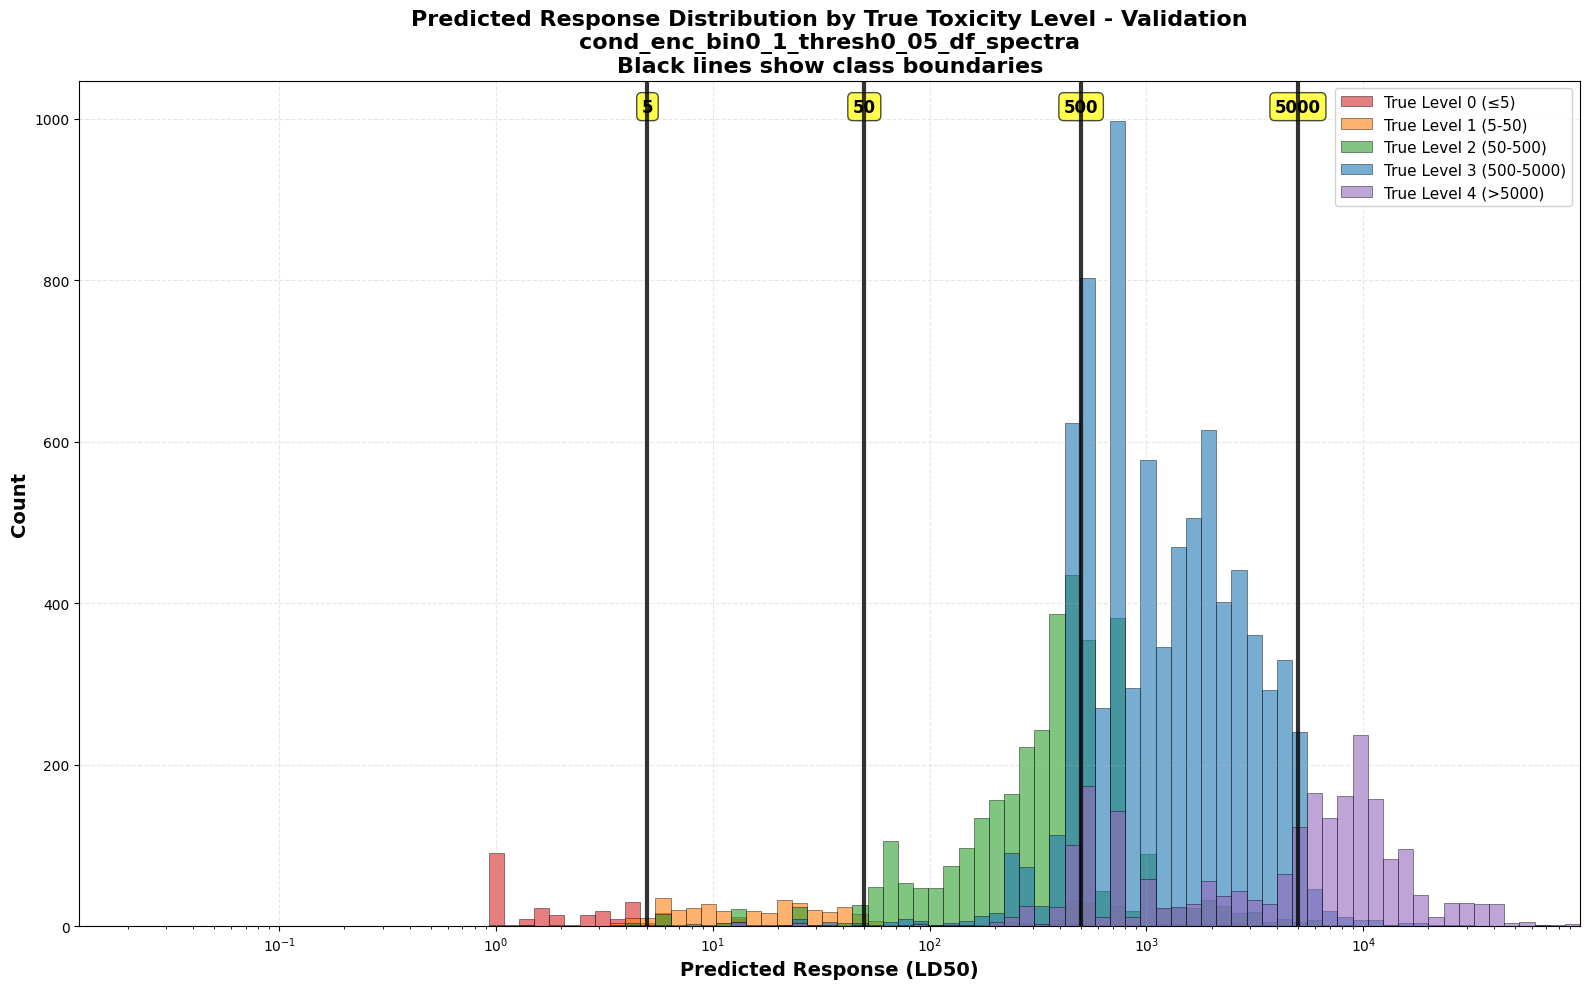

Creating true response histogram...


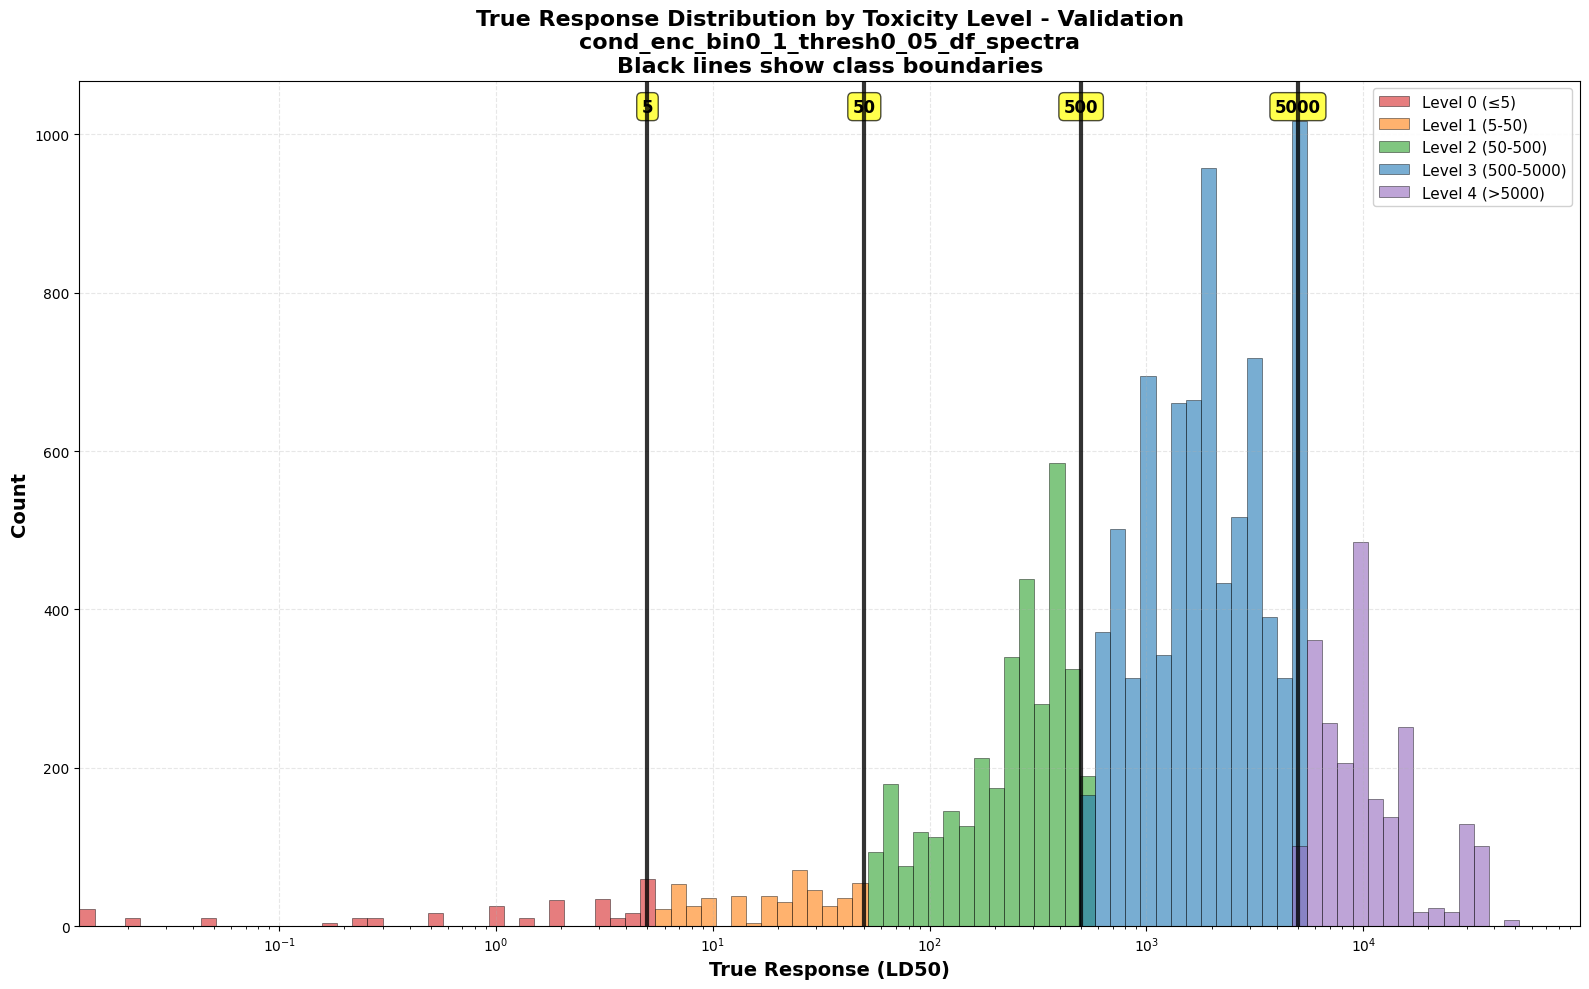

Both histograms created with matched scales!


In [55]:
# Example: Create both predicted and true response histograms with automatic matched scaling
plot_df_pred, plot_df_true = create_matched_histograms(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2",
    file_name="cond_enc_bin0_1_thresh0_05_df_spectra.parquet",
    super_test=False,
    test_only=False,
    stack = False
)



# Visualizations Excecutions

## Cond Enc 12e1e2

Found 48 total files, processing 30 matching specified bins/thresholds


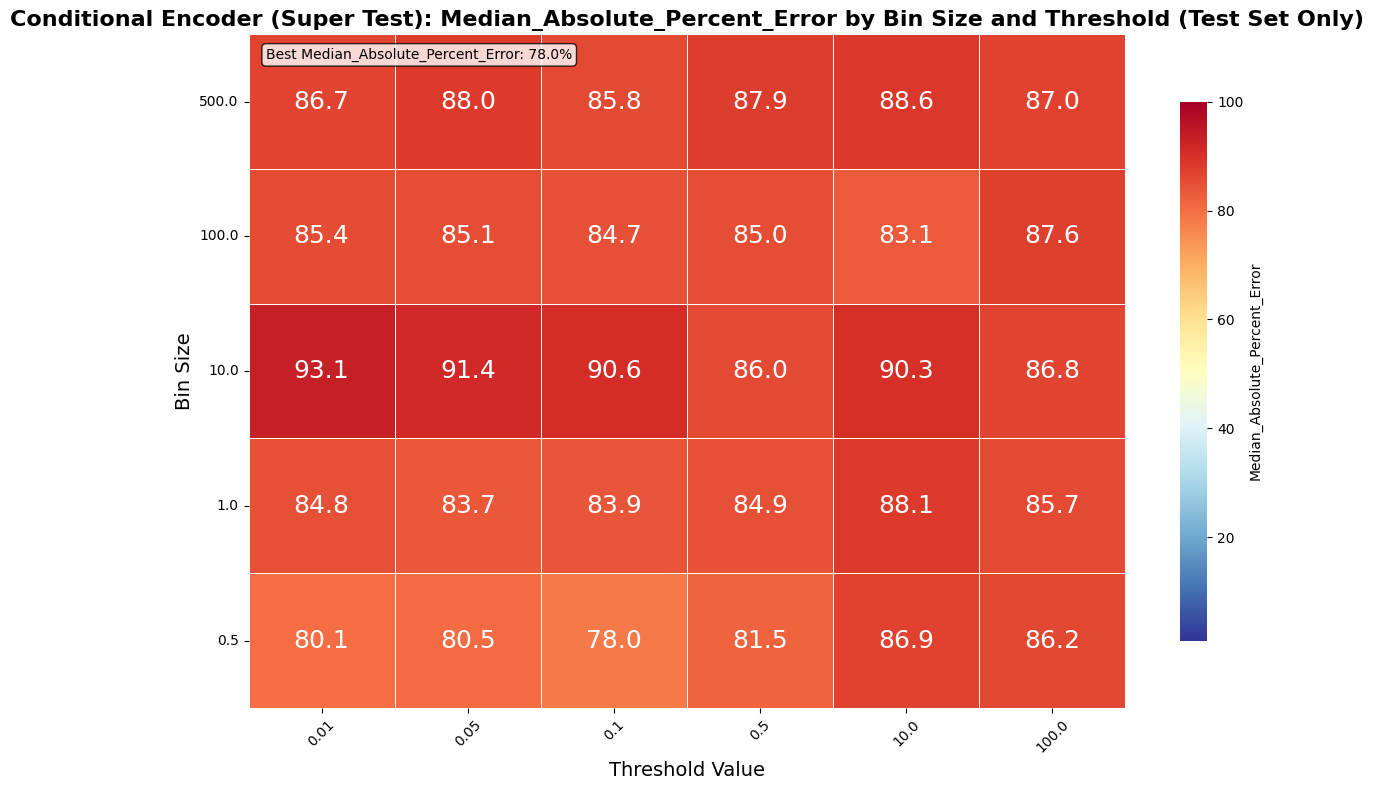

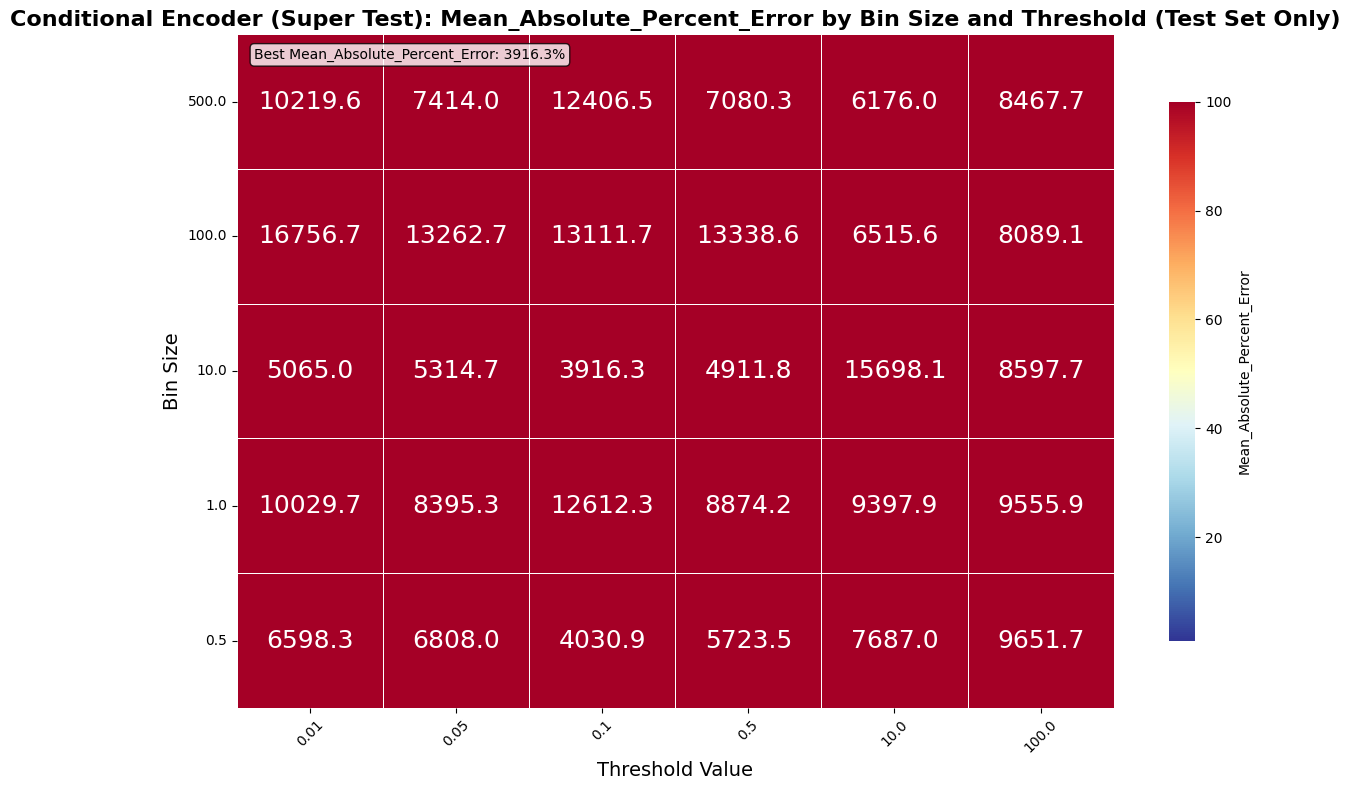

In [67]:
create_conditional_encoder_heatmaps(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_12e1e2",
    super_test=True,
    test_only=True,
    train_only=False,
    bins=[0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
)

Loading: /home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_12e1e2_super_test/super_test_cond_enc_bin1_thresh0_05_df_spectra.parquet
Filtered to test set only: 946 samples


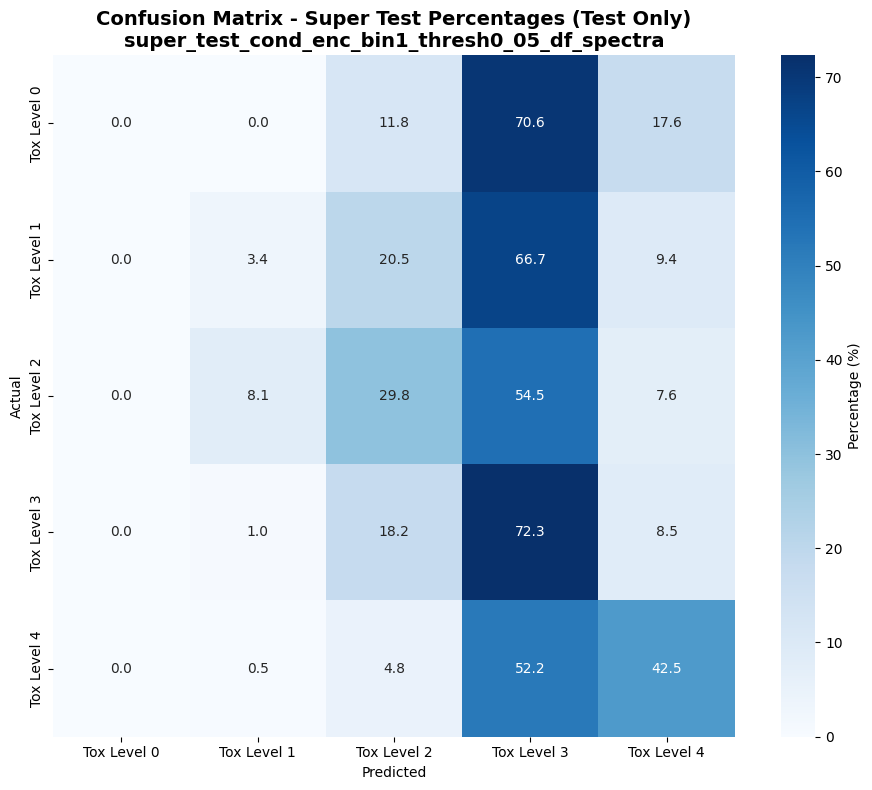

In [57]:
cm_percent, df = create_toxicity_confusion_matrix(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_12e1e2",
    file_name="cond_enc_bin1_thresh0_05_df_spectra.parquet",
    test_only=True,
    super_test=True
)

## Cond Enc 1234e1e2 No Sig, No Weight

Found 48 total files, processing 30 matching specified bins/thresholds


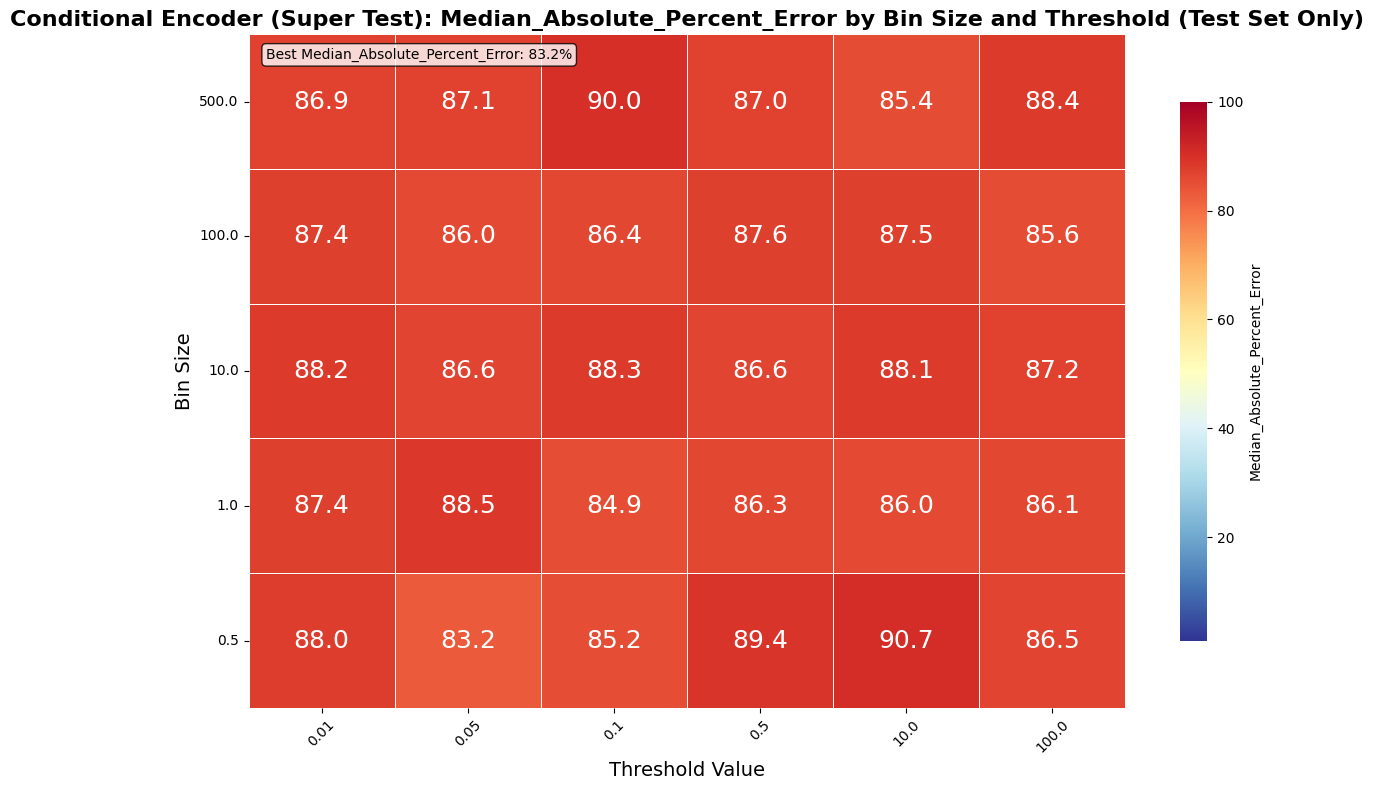

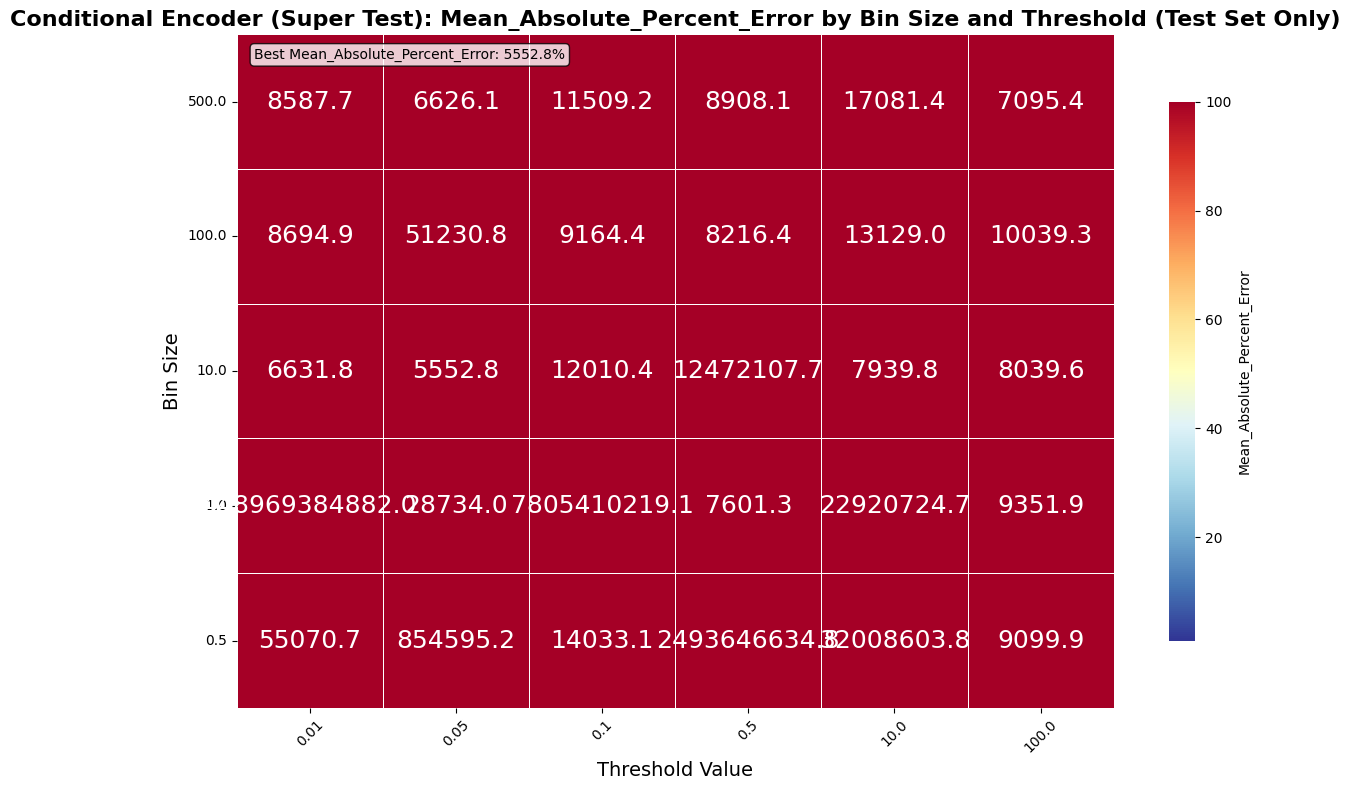

In [68]:
create_conditional_encoder_heatmaps(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_nosig_noweight",
    super_test=True,
    test_only=True,
    train_only=False,
    bins=[0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
)

Loading: /home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_nosig_noweight_super_test/super_test_cond_enc_bin1_thresh0_05_df_spectra.parquet
Filtered to test set only: 946 samples


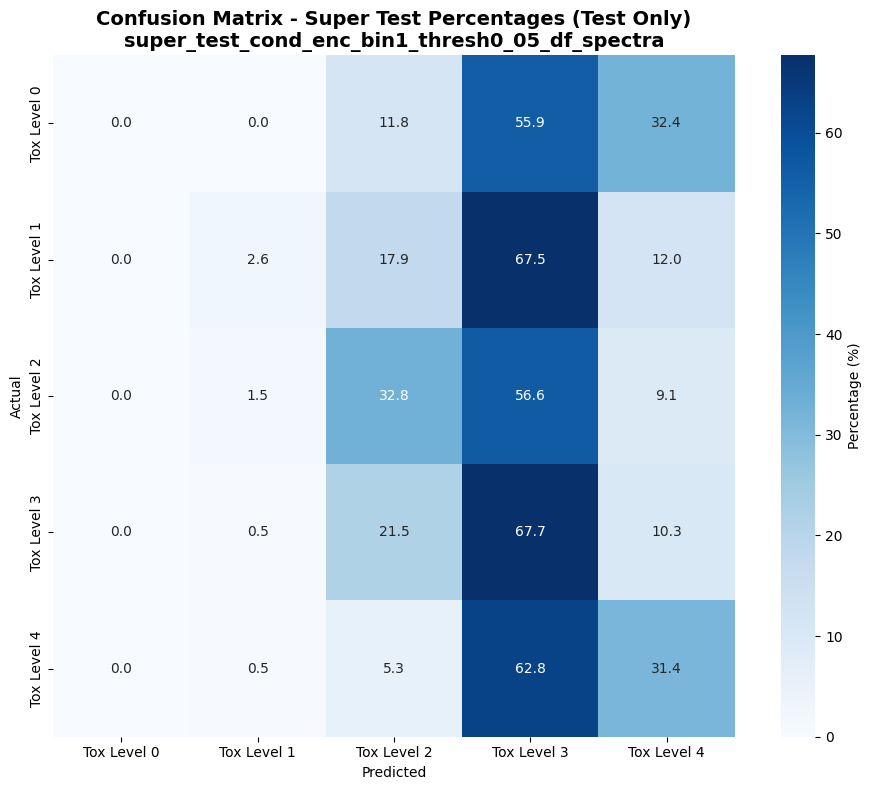

In [59]:
cm_percent, df = create_toxicity_confusion_matrix(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_nosig_noweight",
    file_name="cond_enc_bin1_thresh0_05_df_spectra.parquet",
    test_only=True,
    super_test=True
)

## Cond Enc 1234e1e2 Sig, No Weight

Found 48 total files, processing 30 matching specified bins/thresholds


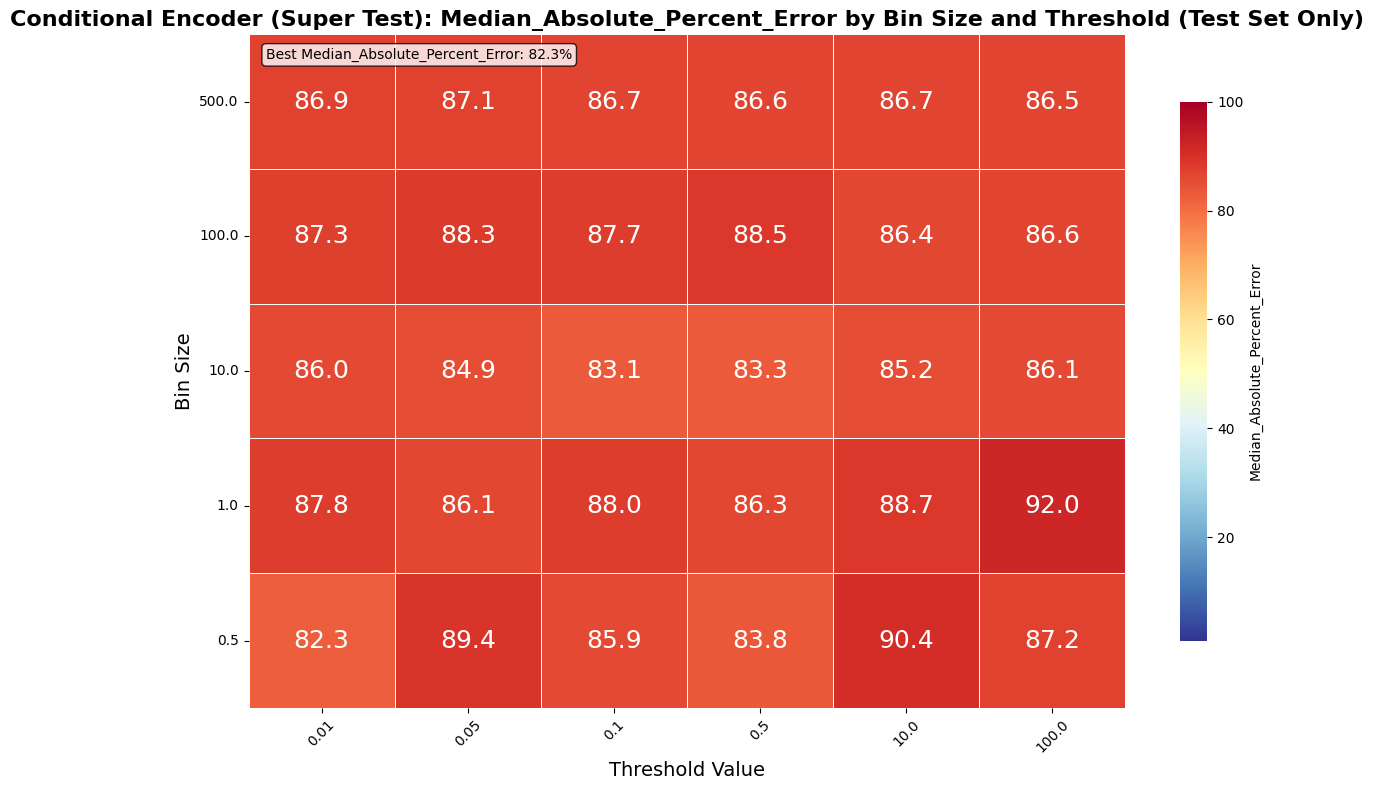

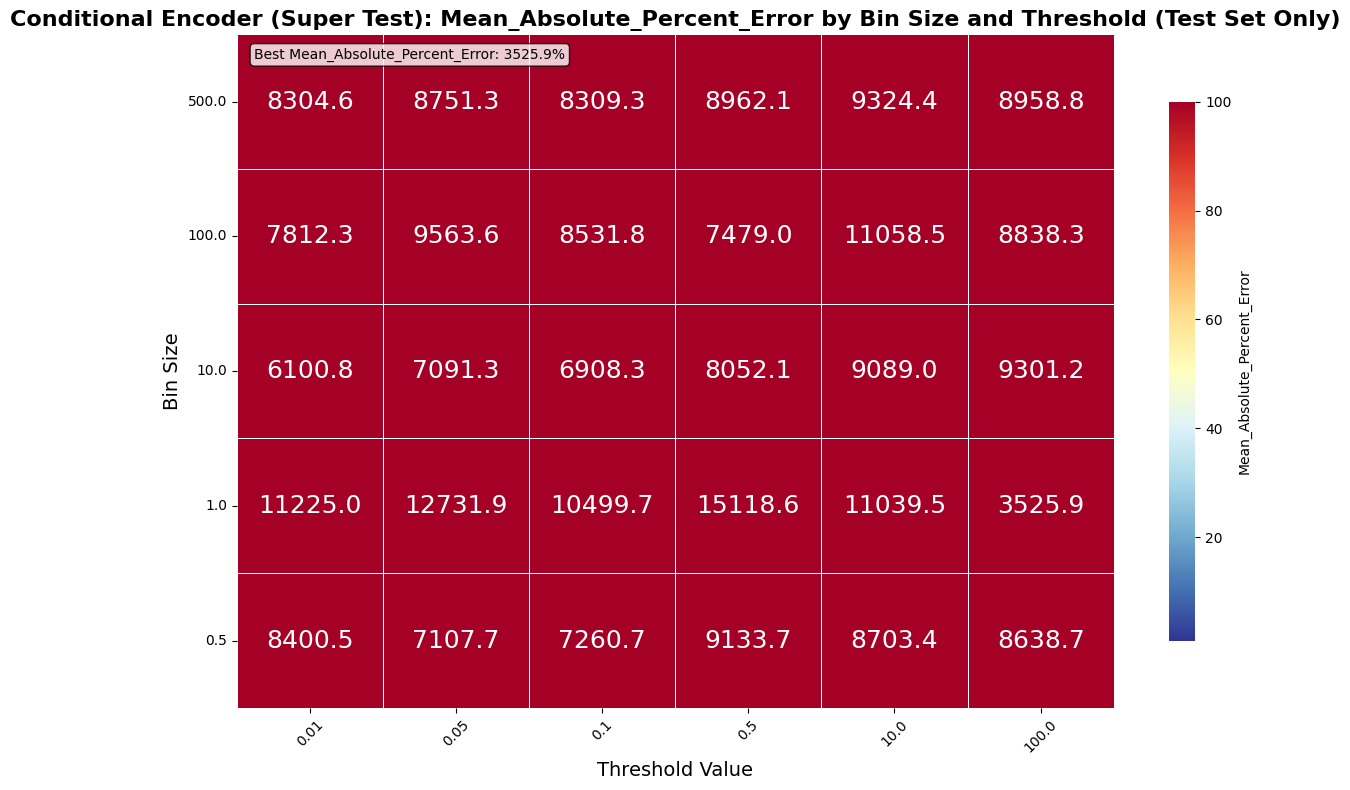

In [69]:
create_conditional_encoder_heatmaps(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_yessig_noweight",
    super_test=True,
    test_only=True,
    train_only=False,
    bins=[0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
)

Loading: /home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_yessig_noweight_super_test/super_test_cond_enc_bin1_thresh0_05_df_spectra.parquet
Filtered to test set only: 946 samples


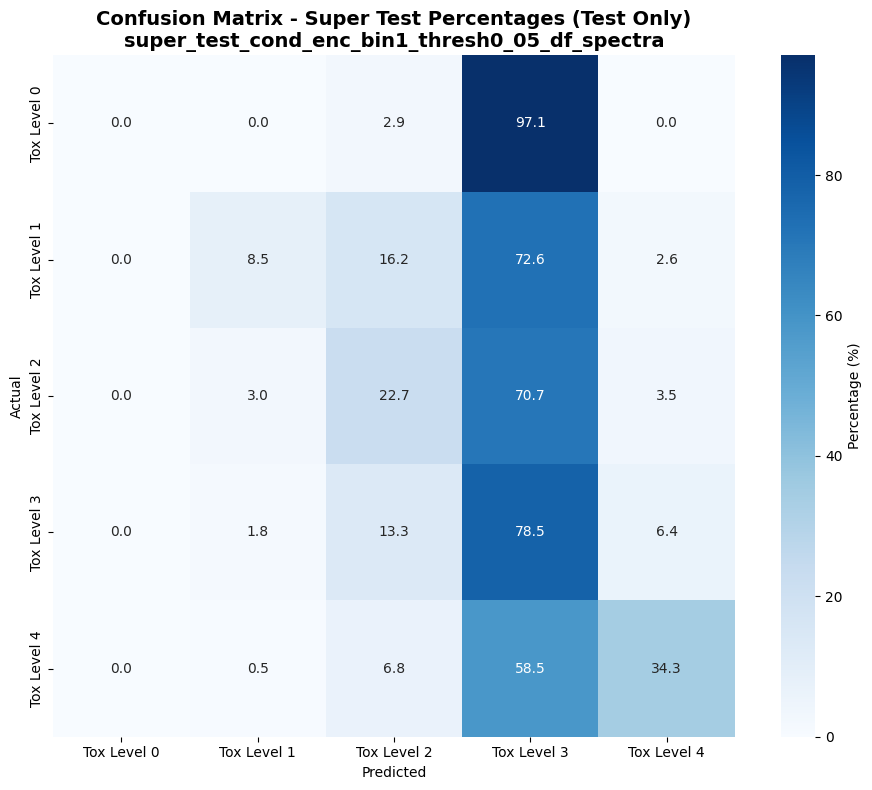

In [61]:
cm_percent, df = create_toxicity_confusion_matrix(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_yessig_noweight",
    file_name="cond_enc_bin1_thresh0_05_df_spectra.parquet",
    test_only=True,
    super_test=True
)

## Cond Enc 1234e1e2 Sig, Weight

Found 143 total files, processing 30 matching specified bins/thresholds


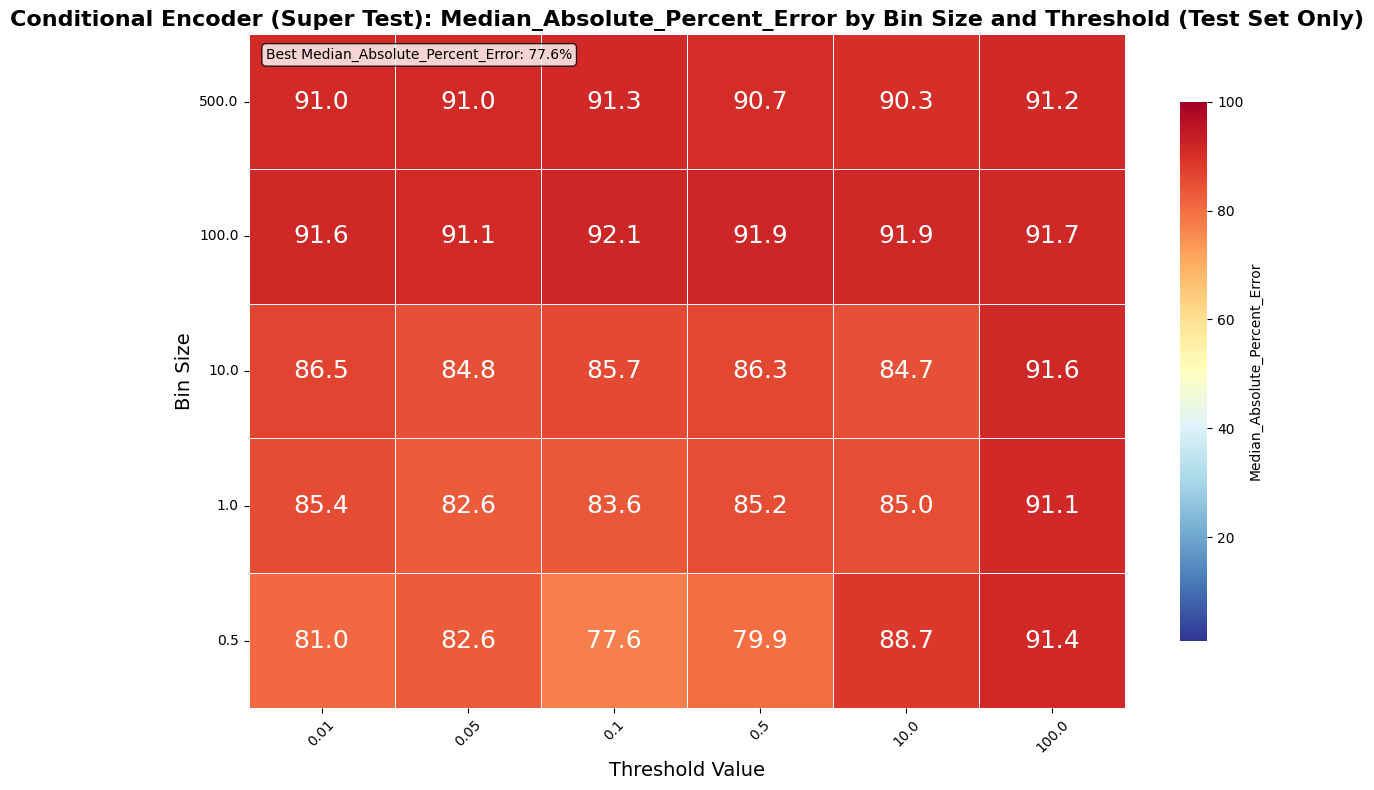

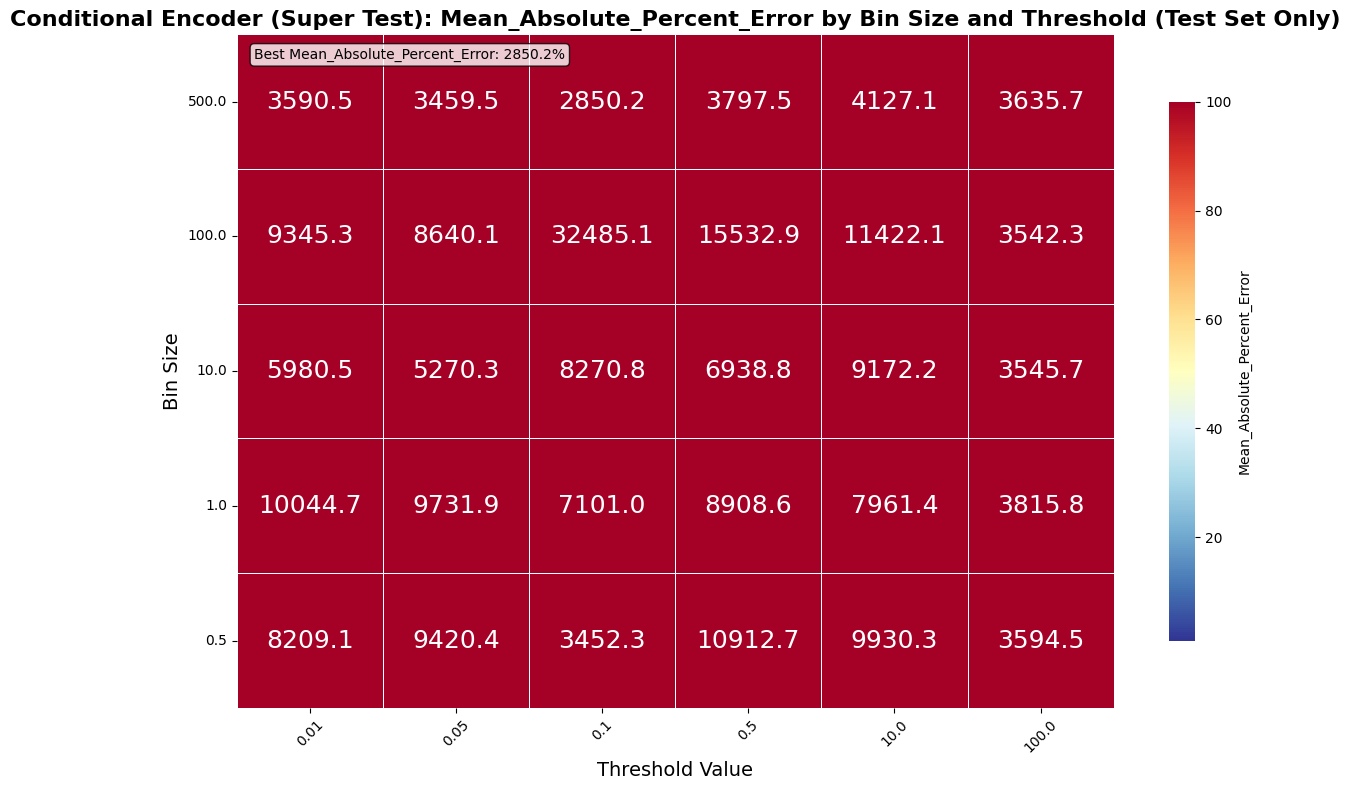

In [70]:
create_conditional_encoder_heatmaps(
    folder_path= "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2",
    super_test=True,
    test_only=True,
    train_only=False,
    bins=[0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
)

Loading: /home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_super_test/super_test_cond_enc_bin1_thresh0_05_df_spectra.parquet
Filtered to test set only: 946 samples


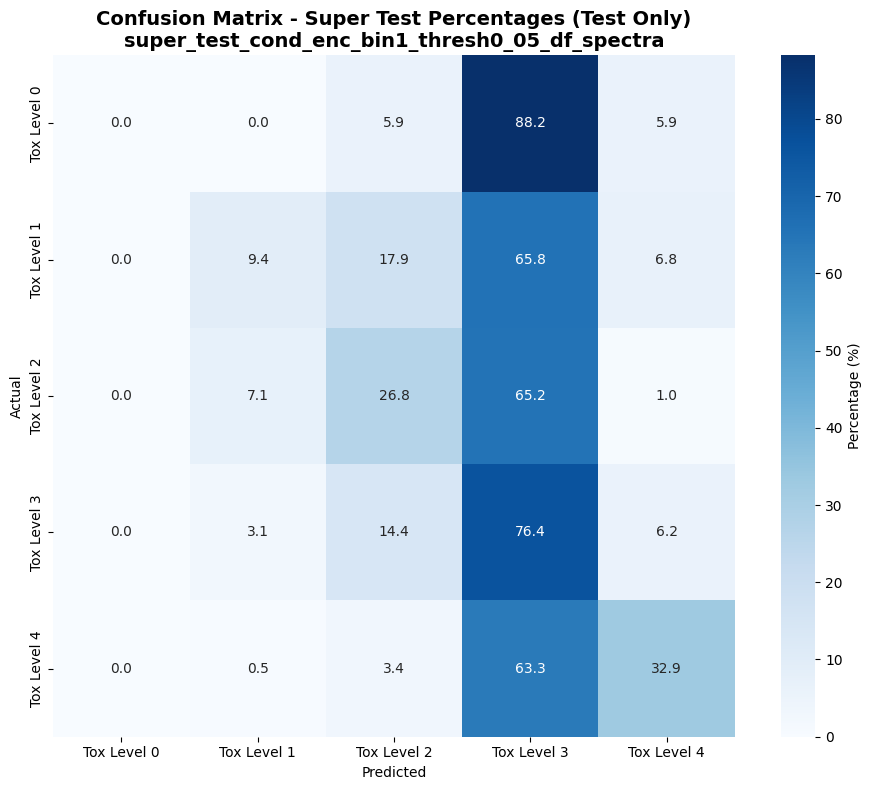

In [63]:
cm_percent, df = create_toxicity_confusion_matrix(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2",
    file_name="cond_enc_bin1_thresh0_05_df_spectra.parquet",
    test_only=True,
    super_test=True
)

## ChemNet Encoder RF

Found 48 total files in /home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_enc_rf_predictor_super_test
Processing 30 files matching specified bins/thresholds with prefix 'enc_rf'


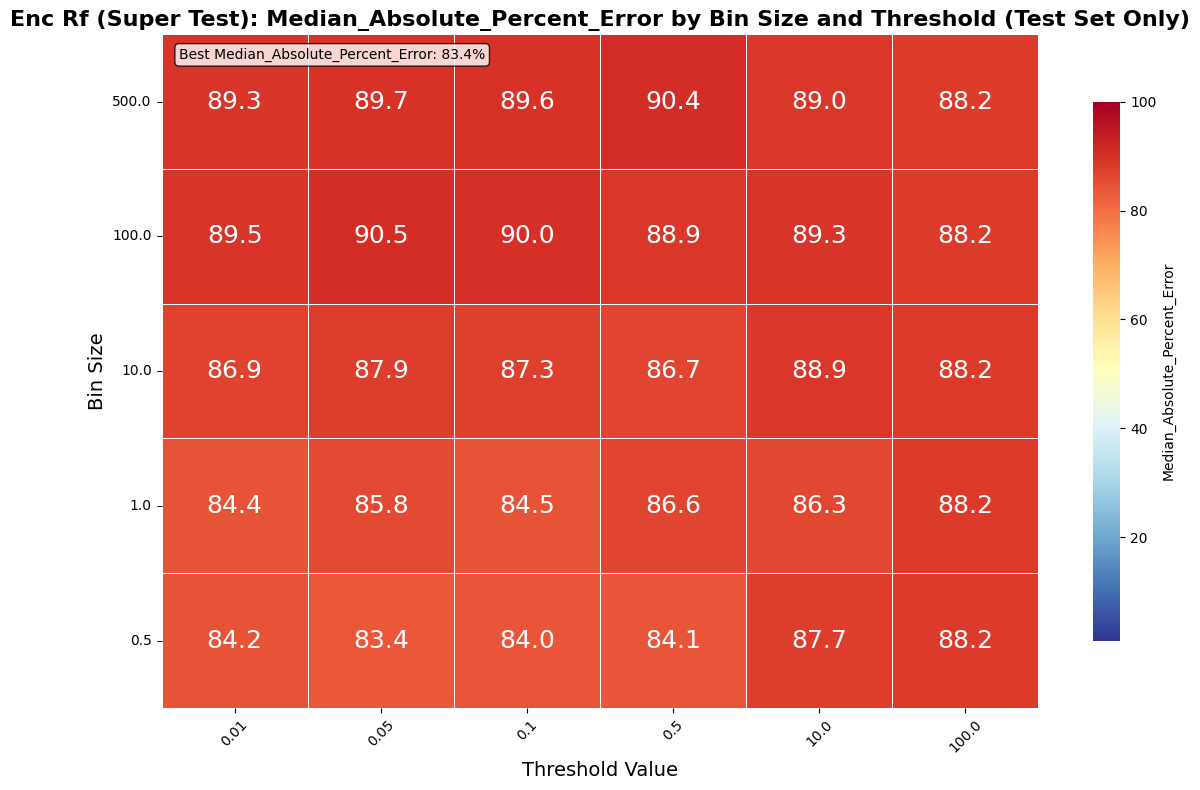

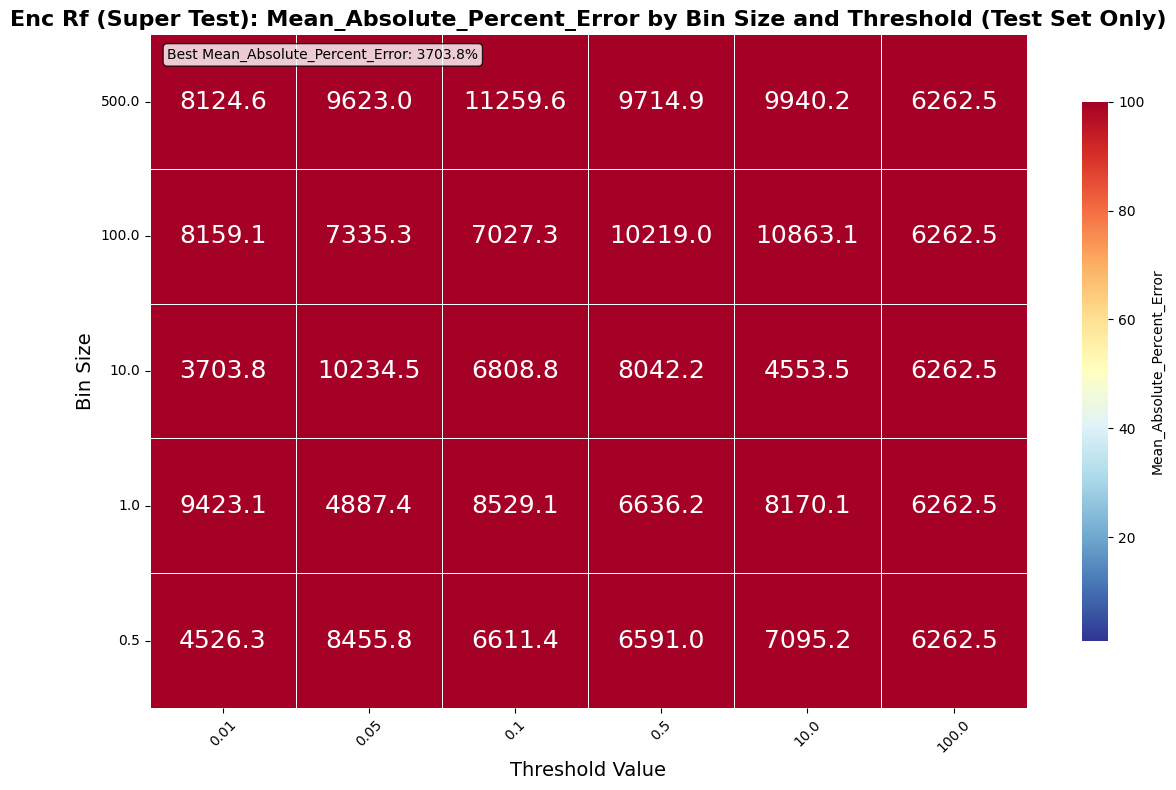

In [64]:
create_conditional_encoder_heatmaps_flexible(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_enc_rf_predictor",
    file_prefix='enc_rf',
    pred_col='rf_tox_pred',
    test_only=True,
    super_test=True,
    bins=[0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
)

Loading: /home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_enc_rf_predictor_super_test/super_test_enc_rf_bin1_thresh0_05_df_spectra.parquet
Filtered to test set only: 946 samples


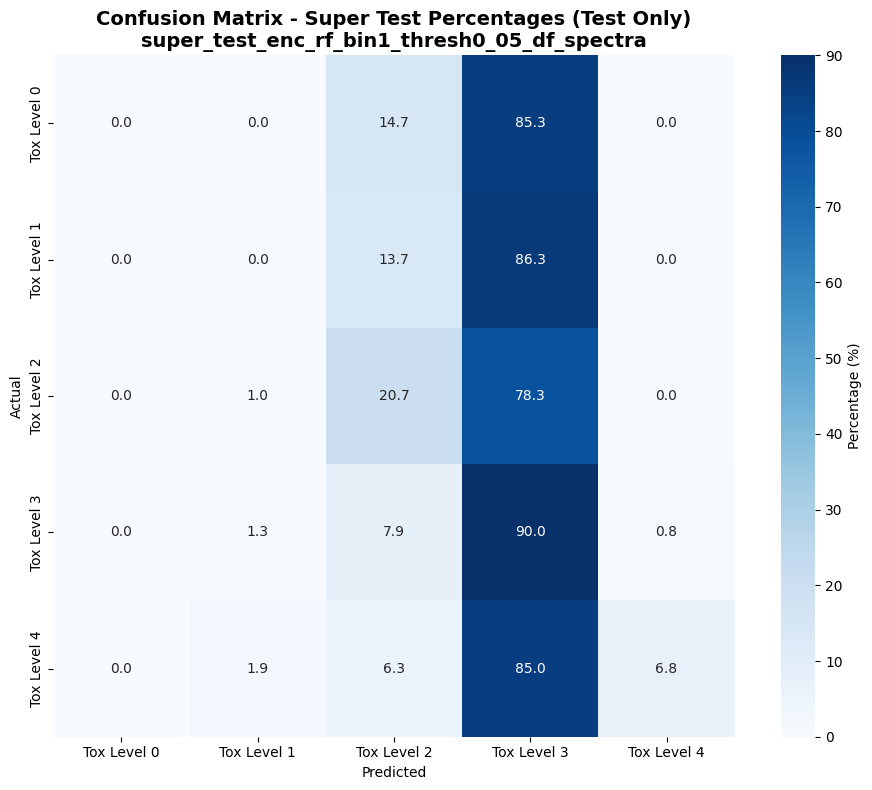

In [65]:
cm_percent, df = create_toxicity_confusion_matrix_flexible(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_enc_rf_predictor",
    file_name="enc_rf_bin1_thresh0_05_df_spectra.parquet",
    pred_col='rf_tox_pred',
    test_only=True,
    super_test=True
)

## Spectra RF

Found 48 total files in /home/dlipsey/MITLincolnLabs/MIT_LL_data/random_forest_df6
Processing 30 files matching specified bins/thresholds with prefix 'rf_direct'


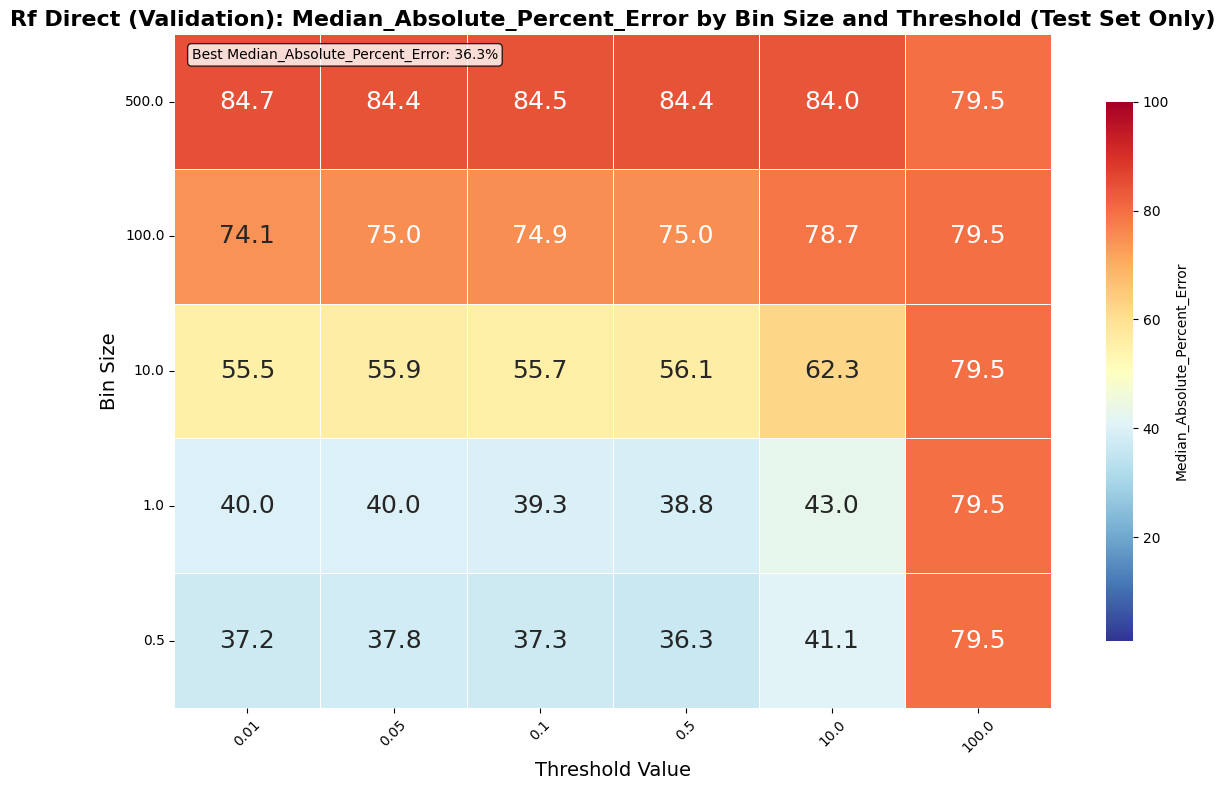

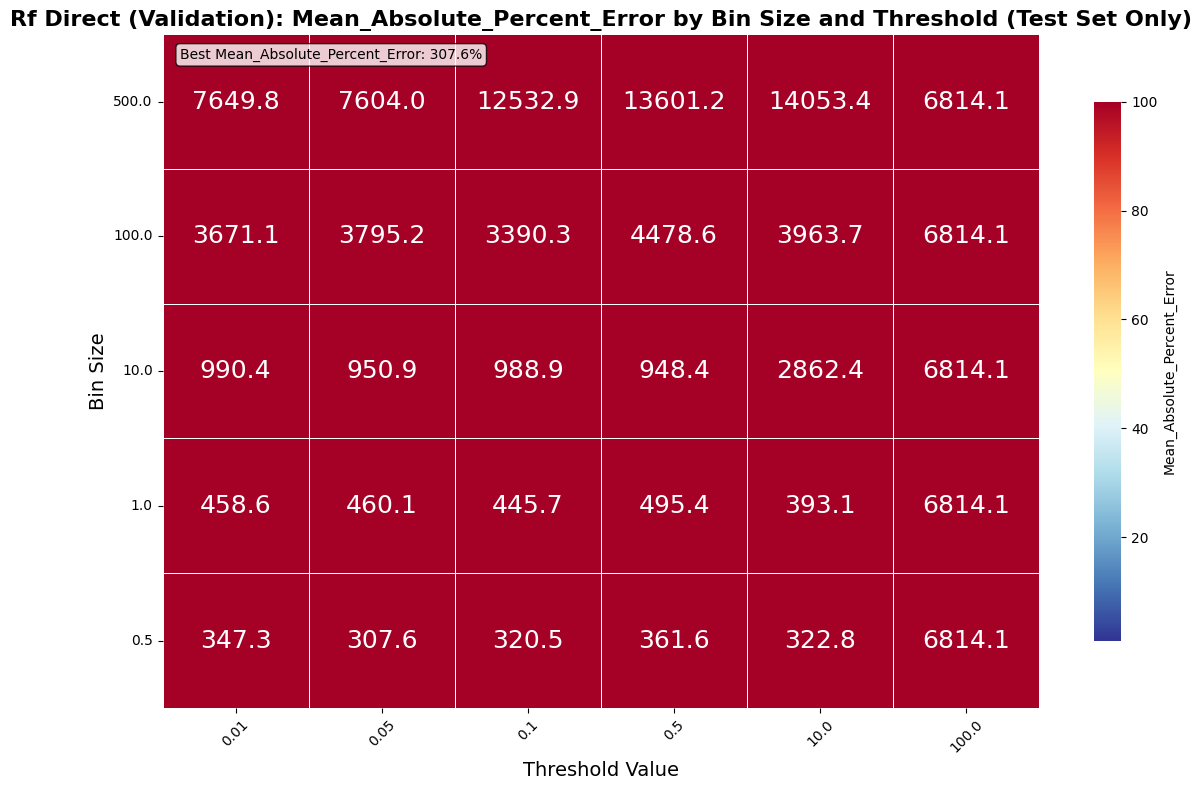

In [73]:
create_conditional_encoder_heatmaps_flexible(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/random_forest_df6",
    file_prefix='rf_direct',
    pred_col='rf_direct_tox_pred',
    test_only=True,
    super_test=False,
    bins=[0.5, 1, 10, 100, 500],
    thresholds=[0.01, 0.05, 0.1, 0.5, 10, 100],
    vmin=1.0,
    vmax=100.0,
    figsize=(12, 8),
    save_plots=False,
    save_path=None
)

# Best Model Histogram

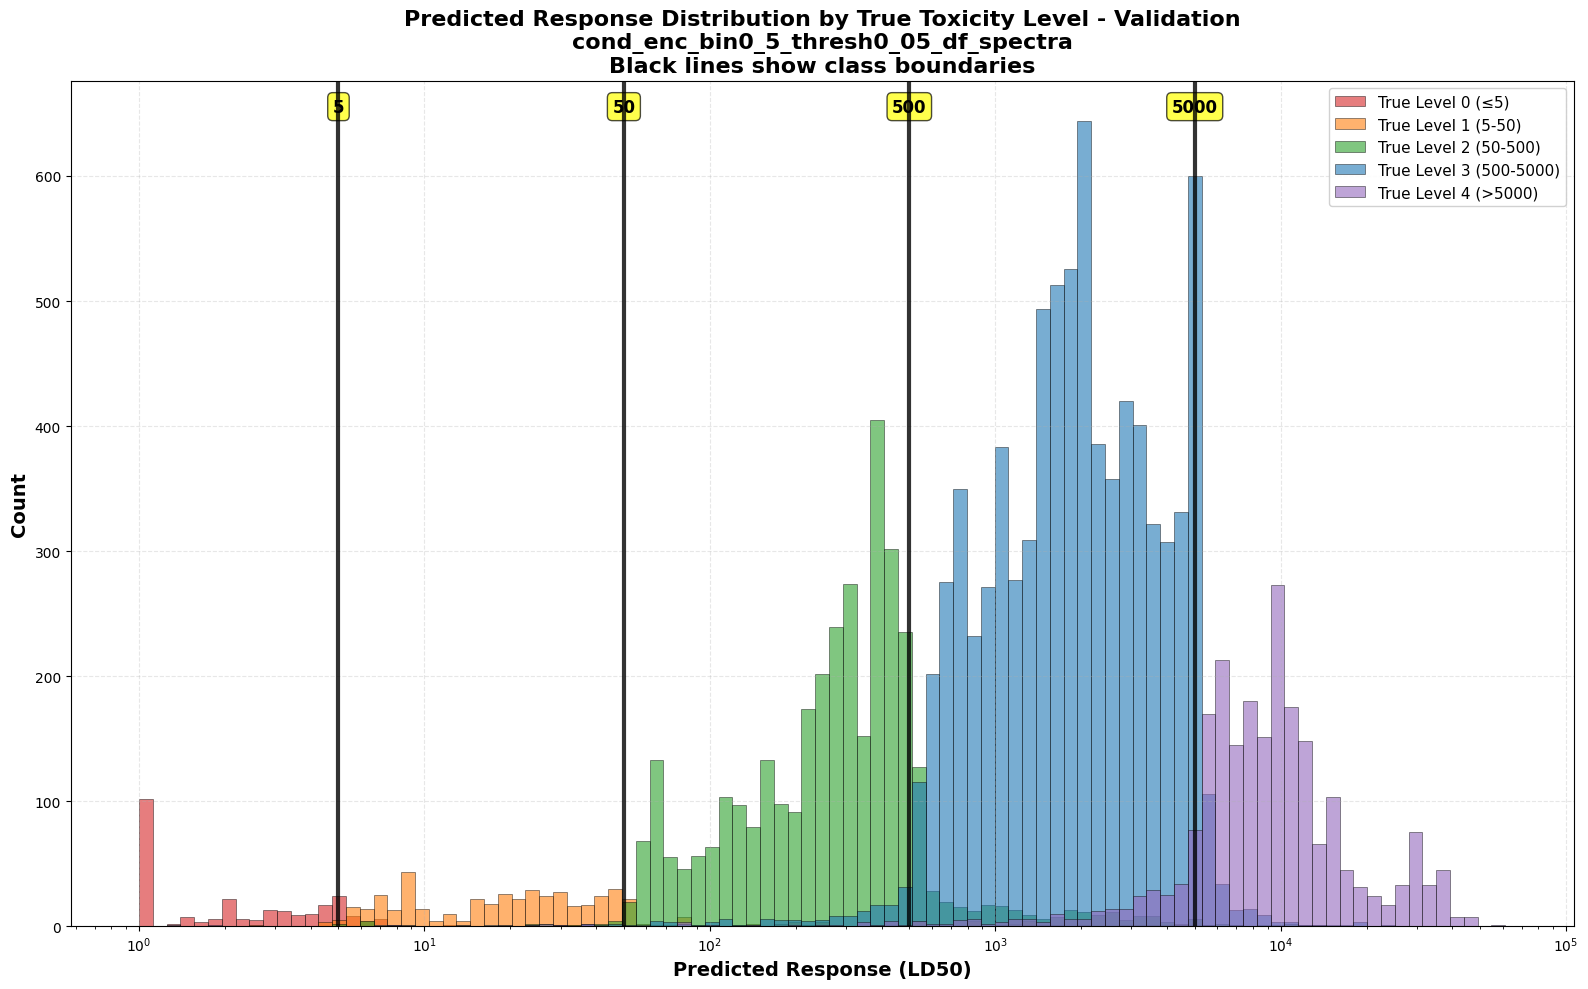

,Predicted_Response,True_Toxicity_Level,Predicted_Toxicity_Level,True_Response,Is_Correct
0,3426.353027,3,3,3335.479075,True
1,3431.941895,3,3,3335.479075,True
2,2118.079834,3,3,3335.479075,True
3,1963.854614,3,3,3335.479075,True
4,3437.815430,3,3,3335.479075,True
...,...,...,...,...,...
14460,1.000133,0,0,0.270000,True
14461,1.000126,0,0,0.270000,True
14462,1.000136,0,0,0.270000,True
14463,1.000141,0,0,0.270000,True


In [77]:
create_toxicity_histogram(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2",
    file_name="cond_enc_bin0_5_thresh0_05_df_spectra.parquet",
    super_test=False,
    test_only=False,
    shared_bins=None,
    shared_xlim=None,
    stack=False
)

